In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
start_date = "2020-01-01"
end_date = "2026-05-06"
universe = [
    "ES=F", # risk/growth
    "NQ=F", # liquidity/growth duration
    "ZN=F", # rates
    "CL=F", # inflation and geopolitics
    "GC=F", # real yields and monetary stress
    "^VIX", # risk stress and volatility
    "DX-Y.NYB", # global liquidity
    "HYG" # credit risk
]
tradable_assets = [
    "ES=F",
    "NQ=F",
    "ZN=F",
    "CL=F",
    "GC=F",
    "HYG"
]

condition_assets = [
    "^VIX",
    "DX-Y.NYB",
    "ZN=F"
]

In [44]:
data = yf.download(universe, start=start_date, end=end_date)
data.head()

[*********************100%***********************]  8 of 8 completed


Price           Close                                                       \
Ticker           CL=F   DX-Y.NYB     ES=F         GC=F        HYG     NQ=F   
Date                                                                         
2020-01-02  61.180000  96.849998  3259.00  1524.500000  62.905914  8891.75   
2020-01-03  63.049999  96.839996  3235.50  1549.199951  62.841820  8810.00   
2020-01-06  63.270000  96.669998  3243.50  1566.199951  62.777706  8847.50   
2020-01-07  62.700001  96.980003  3235.25  1571.800049  62.720722  8853.00   
2020-01-08  59.610001  97.300003  3260.25  1557.400024  62.777706  8944.50   

Price                               High             ...        Open         \
Ticker            ZN=F   ^VIX       CL=F   DX-Y.NYB  ...        ZN=F   ^VIX   
Date                                                 ...                      
2020-01-02  128.625000  12.47  61.599998  96.870003  ...  128.296875  13.46   
2020-01-03  129.390625  14.02  64.089996  97.110001  ...  128.656250  15.01   
2020-01-06  129.250000  13.85  64.720001  96.900002  ...  129.500000  15.45   
2020-01-07  129.156250  13.79  63.150002  97.089996  ...  129.234375  13.84   
2020-01-08  128.765625  13.45  65.650002  97.330002  ...  129.250000  15.16   

Price          Volume                                                   \
Ticker           CL=F DX-Y.NYB       ES=F   GC=F         HYG      NQ=F   
Date                                                                     
2020-01-02   486873.0      0.0  1416241.0  214.0  15756600.0  416637.0   
2020-01-03   885861.0      0.0  1755057.0  107.0  17342200.0  599887.0   
2020-01-06   724236.0      0.0  1502748.0  416.0  17936900.0  469514.0   
2020-01-07   582649.0      0.0  1293494.0   47.0   9640300.0  510004.0   
2020-01-08  1205710.0      0.0  2279138.0  236.0  16088100.0  723085.0   

Price                       
Ticker           ZN=F ^VIX  
Date                        
2020-01-02  1250468.0  0.0  
2020-01-03  1817748.0  0.0  
2020-01-06  1666524.0  0.0  
2020-01-07  1450885.0  0.0  
2020-01-08  2993268.0  0.0  

[5 rows x 40 columns]

In [45]:
close_df = data["Close"].dropna()
volume_df = data["Volume"]
ret_df = close_df.pct_change()
log_ret_df = np.log(close_df / close_df.shift(1))

/Users/jplatta/repos/trade_lab/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [62]:
sharpes = log_ret_df.mean(axis=0) / log_ret_df.std(axis=0) * np.sqrt(252)

In [64]:
sharpes.shape

(8,)

In [66]:
sharpes.mean() * np.sqrt(6)

np.float64(0.8211931650239768)

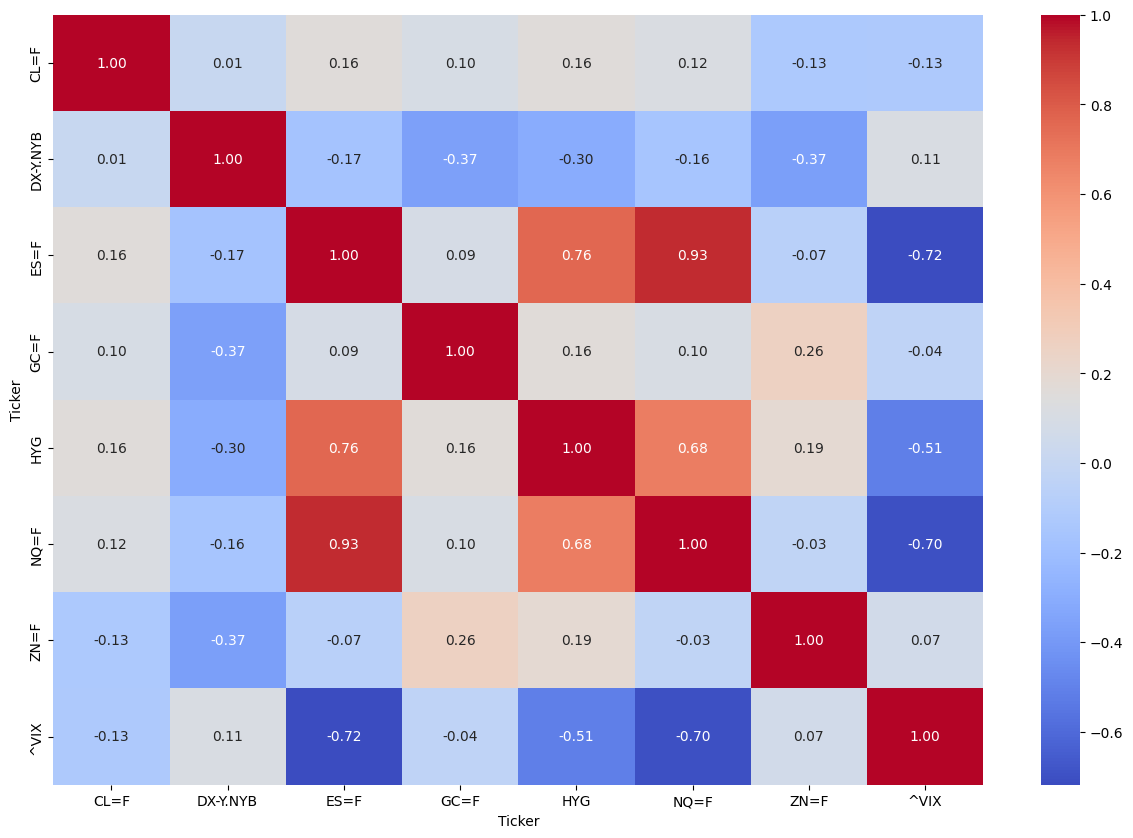

In [61]:
corr = log_ret_df.corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Description
- NQ=F massively outperforming CL=F is the clearest signal. Tech/growth duration assets crushed oil, which usually means AI/liquidity/disinflationary-growth optimism dominated over hard-commodity inflation.-
- GC=F strongly outperforming while DX-Y.NYB drifts slightly down is consistent with falling real-yield pressure and persistent fiscal/monetary concerns.
- ZN=F being roughly flat/slightly negative tells you nominal yields stayed structurally elevated even while gold rallied — meaning gold strength was probably driven more by central bank buying, fiscal concerns, and real-yield expectations than outright bond rallies.
- HYG grinding steadily upward with ES/NQ says credit markets never really priced severe recession risk despite periodic volatility spikes.
- VIX spikes repeatedly failed to produce lasting risk-off cascades. Every stress event got bought.

In other words: “soft-ish growth + AI equity mania + fiscal dominance concerns” rather than “1970s commodity inflation.”

<Axes: xlabel='Date'>

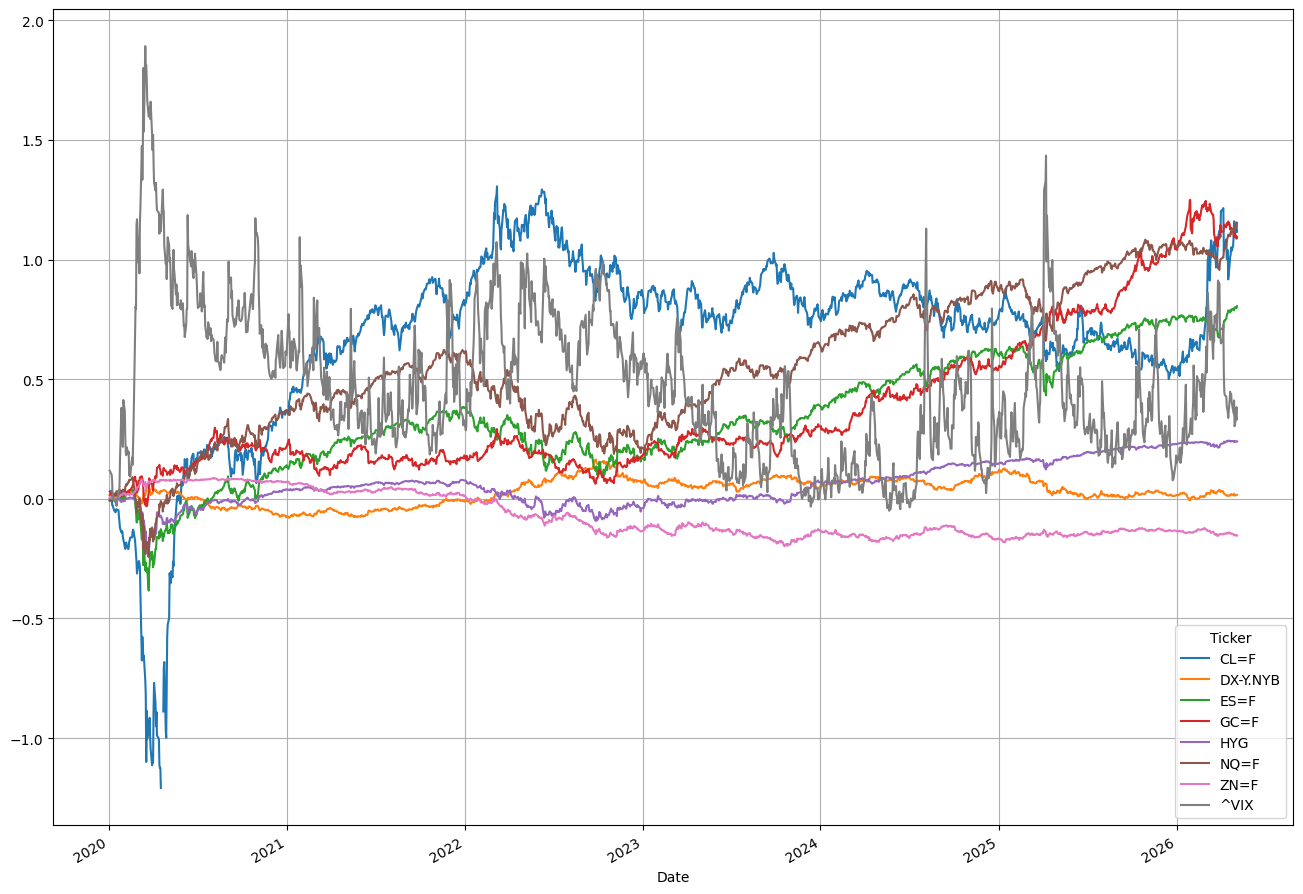

In [46]:
log_ret_df.cumsum().plot(figsize=(16,12), grid=True)

# Portfolio Construction

- equal risk contribution, then tilt by signal strength.

<Axes: xlabel='Date'>

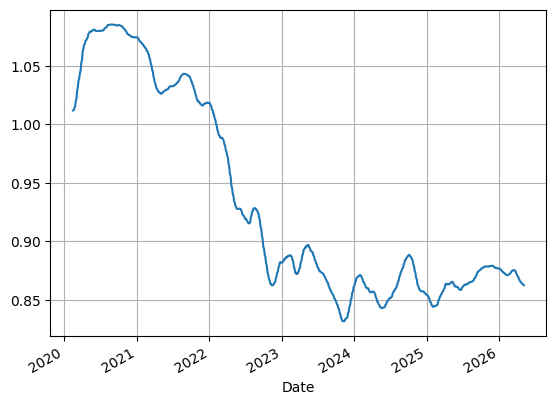

In [52]:
(1 + ret_df['ZN=F'].dropna()).cumprod().rolling(30).mean().plot(grid=True)

In [55]:
ret_df.loc['2026-03-01':,'CL=F']

Date
2026-03-02    0.062817
2026-03-03    0.046750
2026-03-04    0.001341
2026-03-05    0.085052
2026-03-06    0.122084
2026-03-09    0.042574
2026-03-10   -0.119447
2026-03-11    0.045536
2026-03-12    0.097192
2026-03-13    0.031129
2026-03-16   -0.052781
2026-03-17    0.028984
2026-03-18    0.001143
2026-03-19   -0.001869
2026-03-20    0.022675
2026-03-23   -0.103641
2026-03-24    0.047884
2026-03-25   -0.021982
2026-03-26    0.046058
2026-03-27    0.054615
2026-03-30    0.032517
2026-03-31   -0.014580
2026-04-01   -0.012428
2026-04-02    0.114063
2026-04-06    0.007800
2026-04-07    0.004804
2026-04-08   -0.164143
2026-04-09    0.036649
2026-04-10   -0.013283
2026-04-13    0.025992
2026-04-14   -0.078724
2026-04-15    0.000110
2026-04-16    0.037244
2026-04-17   -0.114479
2026-04-20    0.068694
2026-04-21    0.028122
2026-04-22    0.009009
2026-04-23    0.031089
2026-04-24   -0.015128
2026-04-27    0.020869
2026-04-28    0.036941
2026-04-29    0.069549
2026-04-30   -0.016935
2026-0

<Axes: xlabel='Date'>

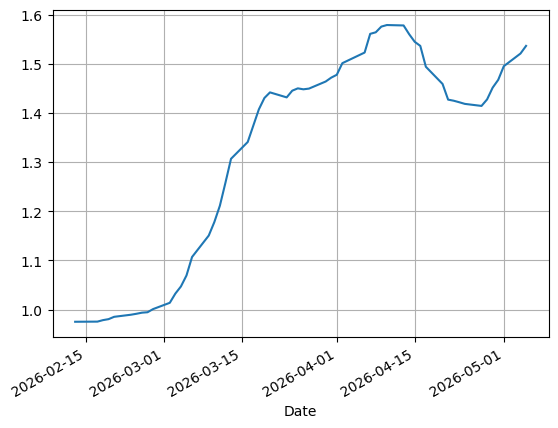

In [57]:
(1 + ret_df.loc['2026-02-01':,'CL=F'].dropna()).cumprod().rolling(10).mean().plot(grid=True)

## Improve Signal

Sharpe: 0.44
Annualized Return: 0.0217
Annualized Vol: 0.0498
Max Drawdown: -0.0997
Average Gross Leverage: 0.84


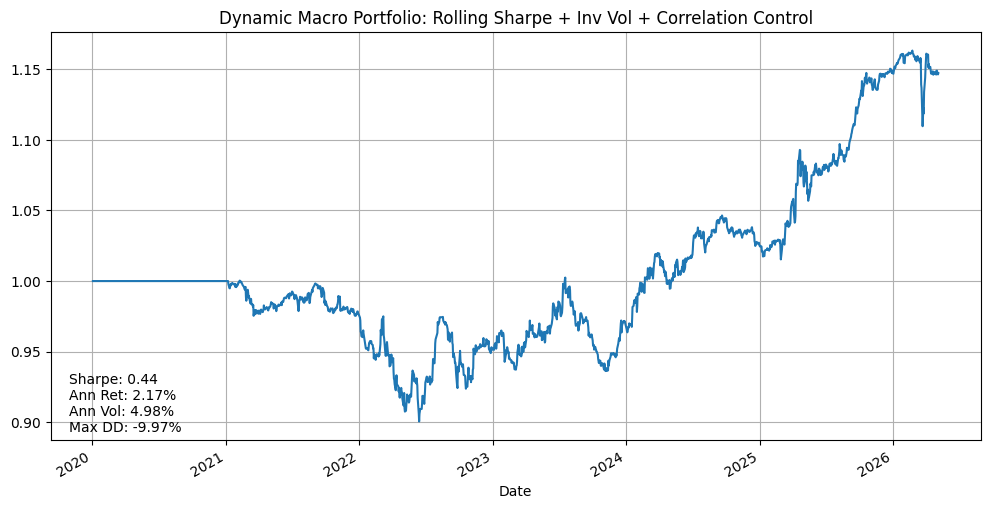

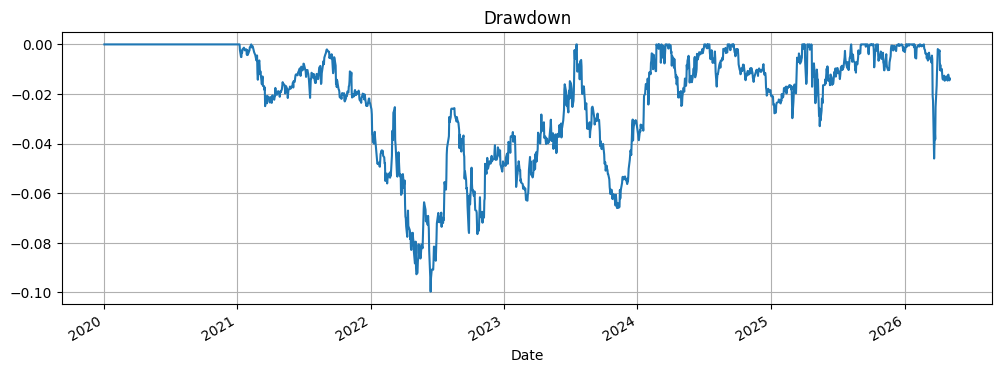

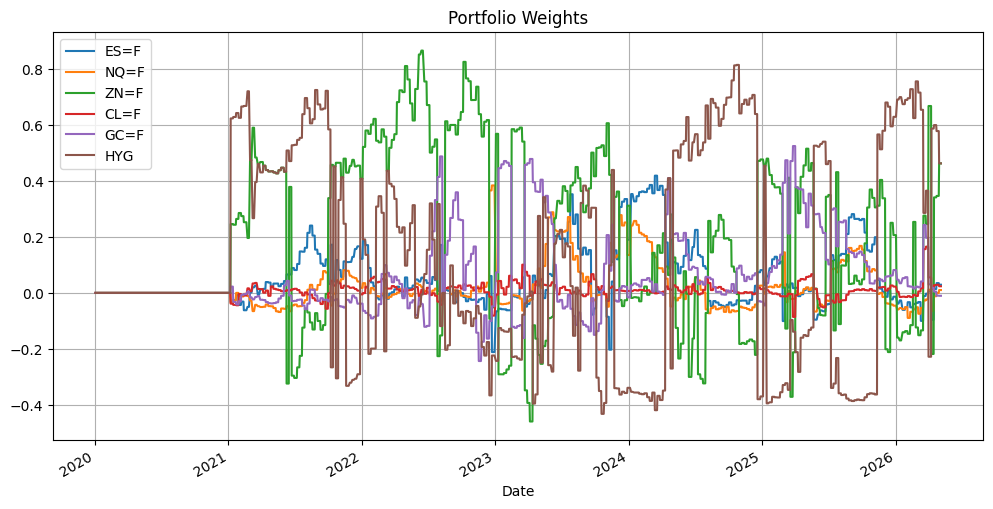

In [84]:
# ------------------------------------------------------------
# Tradable assets vs conditioning assets
# ------------------------------------------------------------

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5          # weekly-ish
target_vol = 0.12           # 12% annualized portfolio vol
max_abs_weight = 0.35       # concentration cap
min_signal = 0.00           # ignore negative Sharpe if long-only style
allow_short = True          # set False for long-only macro basket

vol_floor = 0.05            # annualized floor to avoid exploding weights
cov_lookback = 90
corr_shrink = 0.50          # 0 = no shrink, 1 = diagonal only

# ============================================================
# Rolling Sharpe Signal
# ============================================================

# rolling_mean = returns.rolling(lookback).mean()
# rolling_vol = returns.rolling(lookback).std()
# rolling_sharpe = (rolling_mean / rolling_vol) * np.sqrt(252)

# if allow_short:
#     signal = rolling_sharpe.copy()
# else:
#     signal = rolling_sharpe.clip(lower=0)

# signal = signal.clip(lower=-2.0, upper=2.0)

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1
raw_signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1
trend_filter = (np.sign(fast_trend) * (np.sign(fast_trend) == np.sign(slow_trend)))

signal = raw_signal * trend_filter

# ============================================================
# Inverse Vol Scaling
# ============================================================

ann_vol = rolling_vol * np.sqrt(252)
ann_vol = ann_vol.clip(lower=vol_floor)

raw_scores = signal / ann_vol

# remove weak/noisy exposures
if allow_short:
    raw_scores = raw_scores.where(raw_scores.abs() > min_signal, 0.0)
else:
    raw_scores = raw_scores.where(raw_scores > min_signal, 0.0)

# ============================================================
# Regime Conditioning
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()
dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

risk_multiplier = pd.Series(1.0, index=returns.index)

# VIX stress: reduce risky assets
risk_multiplier[vix > vix_ma * 1.25] *= 0.75

# Dollar strength: tighter global liquidity
risk_multiplier[dxy_mom > 0.03] *= 0.85

# ZN weakness: yields rising / duration pressure
risk_multiplier[zn_mom < -0.02] *= 0.85

conditioned_scores = raw_scores.mul(risk_multiplier, axis=0)

# Optional asset-specific conditioning
conditioned_scores.loc[:, ["ES=F", "NQ=F", "HYG"]] = conditioned_scores[
    ["ES=F", "NQ=F", "HYG"]
].mul(risk_multiplier, axis=0)

# ============================================================
# Correlation / Covariance Control
# ============================================================

def covariance_adjusted_weights(score_row, ret_window):
    score_row = score_row.dropna()

    if score_row.abs().sum() == 0:
        return pd.Series(0.0, index=tradable_assets)

    assets = score_row.index.tolist()
    window = ret_window[assets].dropna()

    if len(window) < 30:
        w = score_row / score_row.abs().sum()
        return w.reindex(tradable_assets).fillna(0.0)

    cov = window.cov() * 252

    diag_cov = pd.DataFrame(
        np.diag(np.diag(cov)),
        index=cov.index,
        columns=cov.columns
    )

    # shrink covariance toward diagonal for stability
    cov_shrunk = (1 - corr_shrink) * cov + corr_shrink * diag_cov

    try:
        inv_cov = np.linalg.pinv(cov_shrunk.values)
        raw_w = inv_cov @ score_row.values
        w = pd.Series(raw_w, index=assets)
    except Exception:
        w = score_row.copy()

    if w.abs().sum() > 0:
        w = w / w.abs().sum()

    return w.reindex(tradable_assets).fillna(0.0)


weights = pd.DataFrame(index=returns.index, columns=tradable_assets, dtype=float)

for i, date in enumerate(returns.index):
    if i < max(lookback, cov_lookback):
        weights.loc[date] = 0.0
        continue

    score_row = conditioned_scores.loc[date]
    ret_window = returns.iloc[i - cov_lookback:i]

    weights.loc[date] = covariance_adjusted_weights(score_row, ret_window)

# ============================================================
# Concentration Cap
# ============================================================

def cap_and_renormalize(row, max_abs_weight=0.35):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(lower=-max_abs_weight, upper=max_abs_weight)

    if row.abs().sum() > 0:
        row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Weekly Rebalance
# ============================================================

rebalance_mask = np.arange(len(weights)) % rebalance_freq == 0

weights_rebalanced = weights.copy()
weights_rebalanced[~rebalance_mask] = np.nan
weights_rebalanced = weights_rebalanced.ffill().fillna(0.0)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (weights_rebalanced.shift(1) * returns).sum(axis=1)

realized_port_vol = gross_port_ret_pre.rolling(lookback).std() * np.sqrt(252)
vol_scalar = target_vol / realized_port_vol
vol_scalar = vol_scalar.clip(lower=0.0, upper=2.0).fillna(0.0)

final_weights = weights_rebalanced.mul(vol_scalar, axis=0)

# Optional max gross leverage cap
max_gross_leverage = 1.0
gross_leverage = final_weights.abs().sum(axis=1)
leverage_scalar = (max_gross_leverage / gross_leverage).clip(upper=1.0).fillna(1.0)
final_weights = final_weights.mul(leverage_scalar, axis=0)

# ============================================================
# Backtest
# ============================================================

pnl = final_weights.shift(1) * returns
port_ret = pnl.sum(axis=1).dropna()

cum_pnl = np.exp(port_ret.cumsum())

sharpe = (port_ret.mean() / port_ret.std()) * np.sqrt(252)
ann_ret = port_ret.mean() * 252
ann_vol_realized = port_ret.std() * np.sqrt(252)

running_max = cum_pnl.cummax()
drawdown = cum_pnl / running_max - 1
max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))
print("Average Gross Leverage:", round(final_weights.abs().sum(axis=1).mean(), 2))

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio: Rolling Sharpe + Inv Vol + Correlation Control"
)

plt.text(
    0.02,
    0.02,
    f"Sharpe: {sharpe:.2f}\nAnn Ret: {ann_ret:.2%}\nAnn Vol: {ann_vol_realized:.2%}\nMax DD: {max_dd:.2%}",
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

## Improve Weighting

Sharpe: 1.04
Annualized Return: 0.1051
Annualized Vol: 0.101
Max Drawdown: -0.11
Average Gross Leverage: 0.64


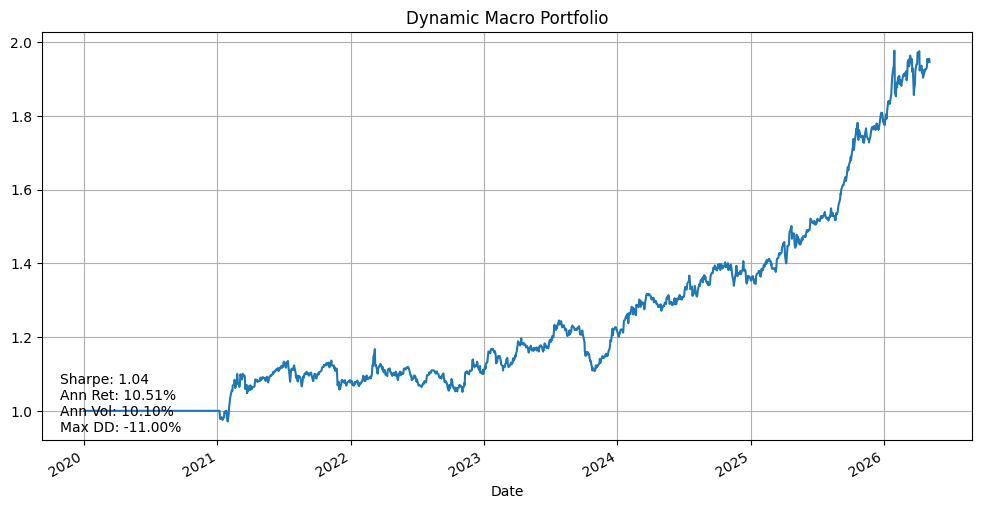

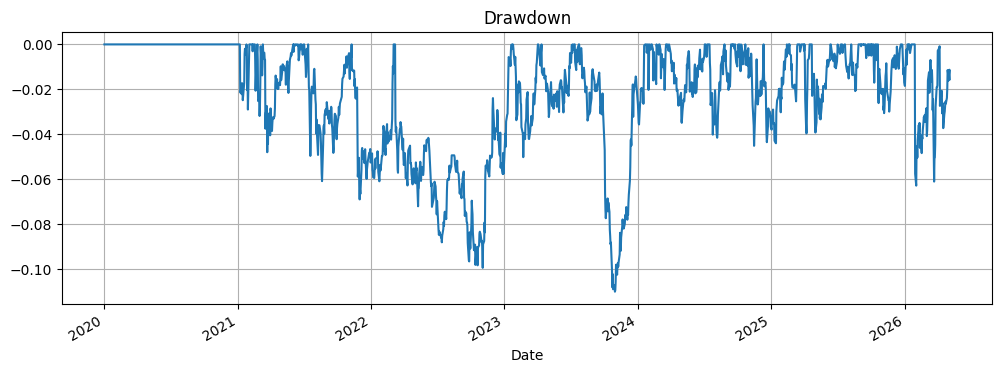

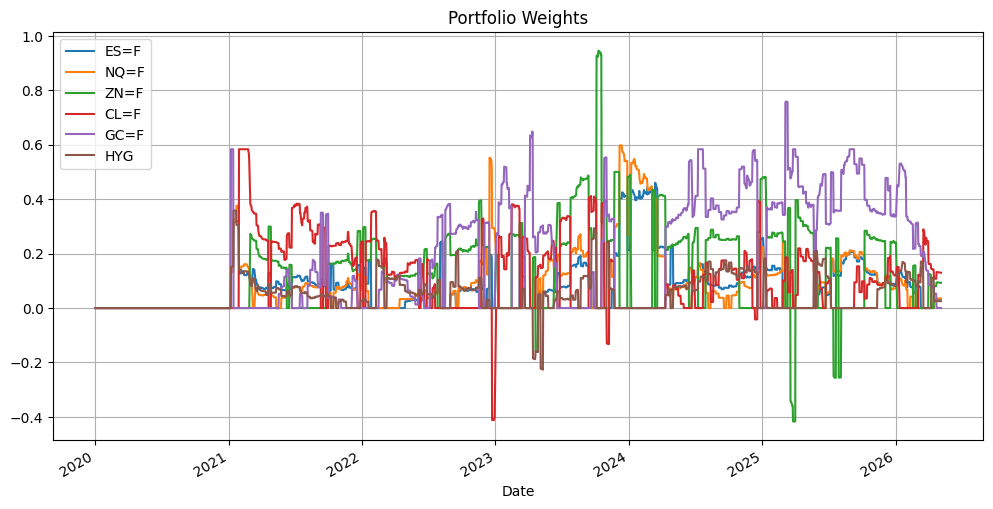

In [96]:
# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5
target_vol = 0.1

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

# ============================================================
# Momentum Ensemble Signal
# ============================================================

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1

signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

# ============================================================
# Trend Persistence Filter
# ============================================================

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1

trend_filter = (
    np.sign(fast_trend)
    * (np.sign(fast_trend) == np.sign(slow_trend))
)

signal = raw_signal * trend_filter

# ============================================================
# Inverse Volatility Scaling
# ============================================================

rolling_vol = (
    returns
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

rolling_vol = rolling_vol.clip(lower=vol_floor)

inv_vol = 1 / rolling_vol

raw_scores = signal * inv_vol

# Remove weak/noisy exposures
if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )
else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Regime Conditioning
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()

dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

risk_multiplier = pd.Series(
    1.0,
    index=returns.index
)

# High volatility regime
risk_multiplier[vix > vix_ma * 1.25] *= 0.75

# Strong dollar = tighter liquidity
risk_multiplier[dxy_mom > 0.03] *= 0.85

# Falling bonds = rising yields / duration pressure
risk_multiplier[zn_mom < -0.02] *= 0.85

conditioned_scores = raw_scores.mul(
    risk_multiplier,
    axis=0
)

# ============================================================
# Macro Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["ES=F", "NQ=F", "HYG"],
    "inflation": ["CL=F", "GC=F"],
    "rates": ["ZN=F"]
}

group_target_weight = {
    "growth": 1/4,
    "inflation": 2/4,
    "rates": 1/4
}

# ============================================================
# Bucketed Weight Construction
# ============================================================

weights = pd.DataFrame(
    index=returns.index,
    columns=tradable_assets,
    dtype=float
)

for date in conditioned_scores.index:

    final_row = pd.Series(
        0.0,
        index=tradable_assets
    )

    for group_name, assets in risk_groups.items():
        group_scores = conditioned_scores.loc[
            date,
            assets
        ].copy()

        # Skip empty group
        if group_scores.abs().sum() == 0:
            continue

        # Normalize within group
        group_weights = (
            group_scores
            / group_scores.abs().sum()
        )

        # Allocate group risk budget
        group_weights *= group_target_weight[group_name]

        final_row.loc[assets] = group_weights

    weights.loc[date] = final_row

# ============================================================
# Concentration Cap
# ============================================================

def cap_and_renormalize(
    row,
    max_abs_weight=0.35
):

    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Weekly Rebalance
# ============================================================

rebalance_mask = (
    np.arange(len(weights))
    % rebalance_freq
    == 0
)

weights_rebalanced = weights.copy()

weights_rebalanced[~rebalance_mask] = np.nan

weights_rebalanced = (
    weights_rebalanced
    .ffill()
    .fillna(0.0)
)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (
    weights_rebalanced.shift(1)
    * returns
).sum(axis=1)

realized_port_vol = (
    gross_port_ret_pre
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

vol_scalar = (
    target_vol
    / realized_port_vol
)

vol_scalar = (
    vol_scalar
    .clip(lower=0.0, upper=2.0)
    .fillna(0.0)
)

final_weights = weights_rebalanced.mul(
    vol_scalar,
    axis=0
)

# ============================================================
# Gross Exposure Cap (No Leverage)
# ============================================================

gross_leverage = (
    final_weights
    .abs()
    .sum(axis=1)
)

leverage_scalar = (
    max_gross_leverage
    / gross_leverage
).clip(upper=1.0).fillna(1.0)

final_weights = final_weights.mul(
    leverage_scalar,
    axis=0
)

# ============================================================
# Backtest
# ============================================================

pnl = (
    final_weights.shift(1)
    * returns
)

port_ret = pnl.sum(axis=1).dropna()

cum_pnl = np.exp(port_ret.cumsum())

# ============================================================
# Metrics
# ============================================================

sharpe = (
    port_ret.mean()
    / port_ret.std()
) * np.sqrt(252)

ann_ret = port_ret.mean() * 252

ann_vol_realized = (
    port_ret.std()
    * np.sqrt(252)
)

running_max = cum_pnl.cummax()

drawdown = (
    cum_pnl
    / running_max
    - 1
)

max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))
print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Portfolio Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

## Reduce Whipsaws

Sharpe: 0.93
Annualized Return: 0.1705
Annualized Vol: 0.1839
Max Drawdown: -0.195
Average Gross Leverage: 0.81


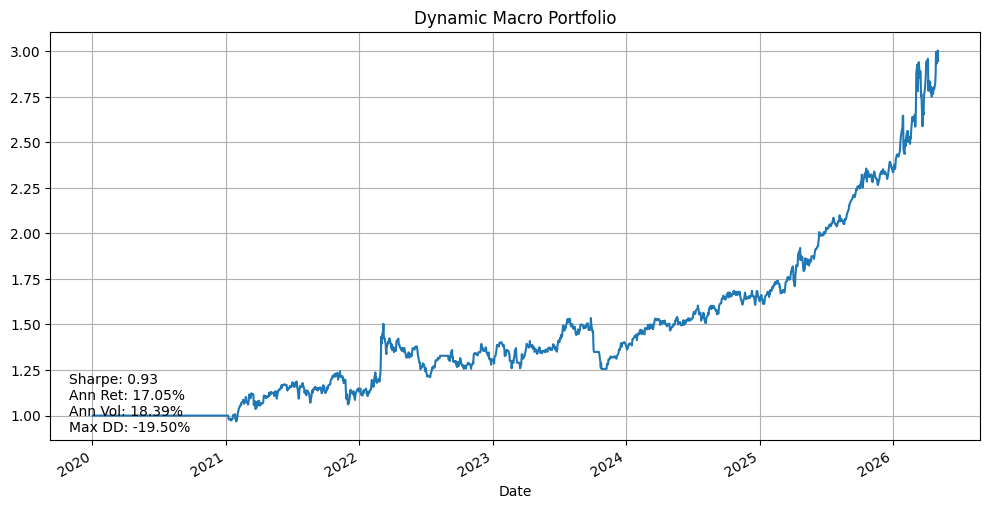

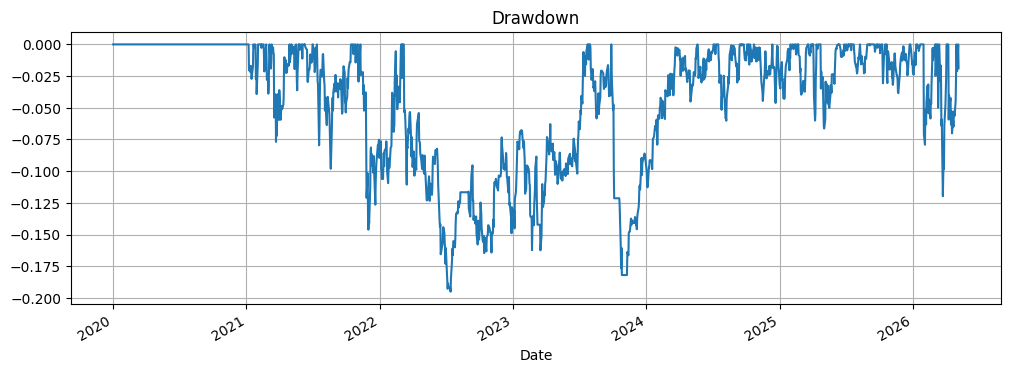

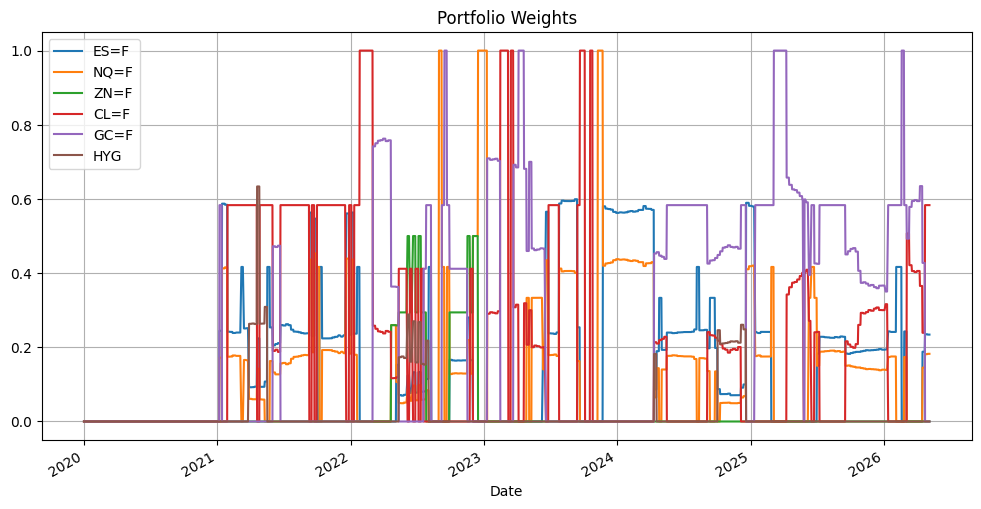

In [105]:
# ============================================================
# NEW: Whipsaw Reduction / Hysteresis Filters
# ============================================================
#
# Added:
# - entry_threshold:
#     minimum signal strength required to ENTER a position
#
# - exit_threshold:
#     smaller threshold required to STAY in a position
#
# This creates hysteresis:
# - harder to enter trades
# - easier to stay in trades
#
# Goal:
# - reduce overtrading
# - reduce chop
# - improve trend persistence
#
# ============================================================

entry_threshold = 0.08
exit_threshold = 0.03

# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5
target_vol = 0.1

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

# ============================================================
# Momentum Ensemble Signal
# ============================================================

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1

raw_signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

# ============================================================
# Trend Persistence Filter
# ============================================================

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1

trend_filter = (
    np.sign(fast_trend)
    * (np.sign(fast_trend) == np.sign(slow_trend))
)

signal = raw_signal * trend_filter

# ============================================================
# NEW: Hysteresis / Deadband Filter
# ============================================================
#
# Logic:
#
# - if signal magnitude > entry_threshold:
#       allow new position
#
# - if signal magnitude < exit_threshold:
#       flatten position
#
# - otherwise:
#       hold PRIOR position
#
# This reduces:
# - noisy flipping
# - false reversals
# - mean-reversion chop
#
# ============================================================

filtered_signal = signal.copy() * 0.0

for col in signal.columns:

    prev_position = 0.0

    for i in range(len(signal)):

        current_signal = signal[col].iloc[i]

        # Missing values
        if pd.isna(current_signal):
            filtered_signal.loc[filtered_signal.index[i], col] = prev_position
            continue

        # Strong enough to enter/reverse
        if abs(current_signal) > entry_threshold:

            prev_position = np.sign(current_signal)

        # Weak enough to fully exit
        elif abs(current_signal) < exit_threshold:

            prev_position = 0.0

        # Otherwise:
        # HOLD prior position
        filtered_signal.loc[
            filtered_signal.index[i],
            col
        ] = prev_position

signal = filtered_signal

# ============================================================
# Inverse Volatility Scaling
# ============================================================

rolling_vol = (
    returns
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)
rolling_vol = rolling_vol.clip(lower=vol_floor)
inv_vol = 1 / rolling_vol
raw_scores = signal * inv_vol

# Remove weak/noisy exposures
if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )
else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Regime Conditioning
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()

dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

risk_multiplier = pd.Series(
    1.0,
    index=returns.index
)

# High volatility regime
risk_multiplier[vix > vix_ma * 1.25] *= 0.75

# Strong dollar = tighter liquidity
risk_multiplier[dxy_mom > 0.03] *= 0.85

# Falling bonds = rising yields / duration pressure
risk_multiplier[zn_mom < -0.02] *= 0.85

conditioned_scores = raw_scores.mul(
    risk_multiplier,
    axis=0
)

# ============================================================
# Macro Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["ES=F", "NQ=F", "HYG"],
    "inflation": ["CL=F", "GC=F"],
    "rates": ["ZN=F"]
}

group_target_weight = {
    "growth": 1/4,
    "inflation": 2/4,
    "rates": 1/4
}

# ============================================================
# Bucketed Weight Construction
# ============================================================

weights = pd.DataFrame(
    index=returns.index,
    columns=tradable_assets,
    dtype=float
)

for date in conditioned_scores.index:

    final_row = pd.Series(
        0.0,
        index=tradable_assets
    )

    for group_name, assets in risk_groups.items():

        group_scores = conditioned_scores.loc[
            date,
            assets
        ].copy()

        if group_scores.abs().sum() == 0:
            continue

        # Normalize WITHIN bucket
        group_weights = (
            group_scores
            / group_scores.abs().sum()
        )

        # Allocate bucket risk budget
        group_weights *= group_target_weight[group_name]

        final_row.loc[assets] = group_weights

    weights.loc[date] = final_row

# ============================================================
# Concentration Cap
# ============================================================

def cap_and_renormalize(
    row,
    max_abs_weight=0.35
):

    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Weekly Rebalance
# ============================================================

rebalance_mask = (
    np.arange(len(weights))
    % rebalance_freq
    == 0
)

weights_rebalanced = weights.copy()

weights_rebalanced[~rebalance_mask] = np.nan

weights_rebalanced = (
    weights_rebalanced
    .ffill()
    .fillna(0.0)
)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (
    weights_rebalanced.shift(1)
    * returns
).sum(axis=1)

realized_port_vol = (
    gross_port_ret_pre
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

vol_scalar = (
    target_vol
    / realized_port_vol
)

vol_scalar = (
    vol_scalar
    .clip(lower=0.0, upper=2.0)
    .fillna(0.0)
)

final_weights = weights_rebalanced.mul(
    vol_scalar,
    axis=0
)

# ============================================================
# Gross Exposure Cap (No Leverage)
# ============================================================

# gross_leverage = (
#     final_weights
#     .abs()
#     .sum(axis=1)
# )

# leverage_scalar = (
#     max_gross_leverage
#     / gross_leverage
# ).clip(upper=1.0).fillna(1.0)

# final_weights = final_weights.mul(
#     leverage_scalar,
#     axis=0
# )
# ============================================================
# Force Fully Invested Portfolio
# ============================================================

gross_exposure = (
    final_weights
    .abs()
    .sum(axis=1)
)

final_weights = final_weights.div(
    gross_exposure,
    axis=0
)

final_weights = final_weights.fillna(0.0)
# ============================================================
# Backtest
# ============================================================

pnl = (
    final_weights.shift(1)
    * returns
)

port_ret = pnl.sum(axis=1).dropna()

cum_pnl = np.exp(port_ret.cumsum())

# ============================================================
# Metrics
# ============================================================

sharpe = (
    port_ret.mean()
    / port_ret.std()
) * np.sqrt(252)

ann_ret = port_ret.mean() * 252

ann_vol_realized = (
    port_ret.std()
    * np.sqrt(252)
)

running_max = cum_pnl.cummax()

drawdown = (
    cum_pnl
    / running_max
    - 1
)

max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))
print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Portfolio Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

## Only run high gross exposure when the cross-asset trend environment is strong.

Sharpe: 0.91
Annualized Return: 0.1534
Annualized Vol: 0.1689
Max Drawdown: -0.1774
Average Gross Leverage: 0.74


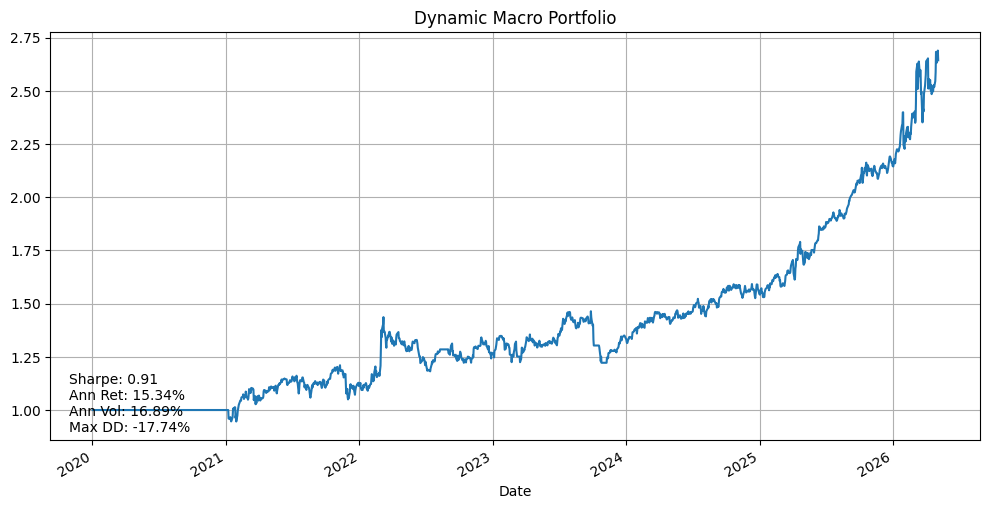

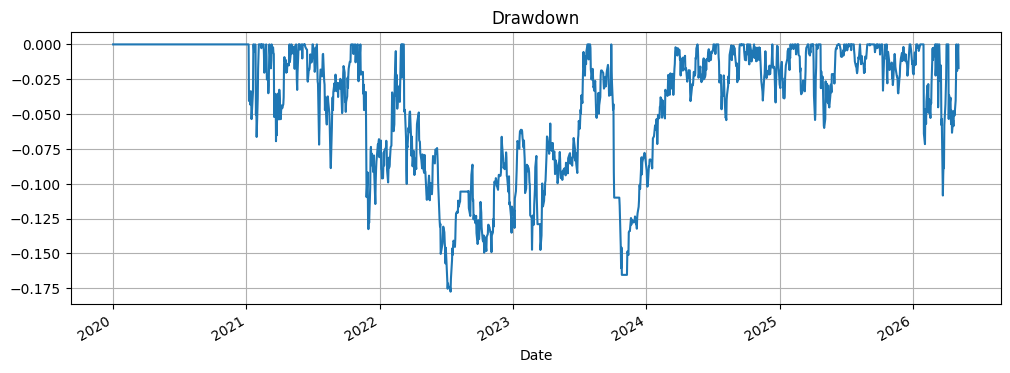

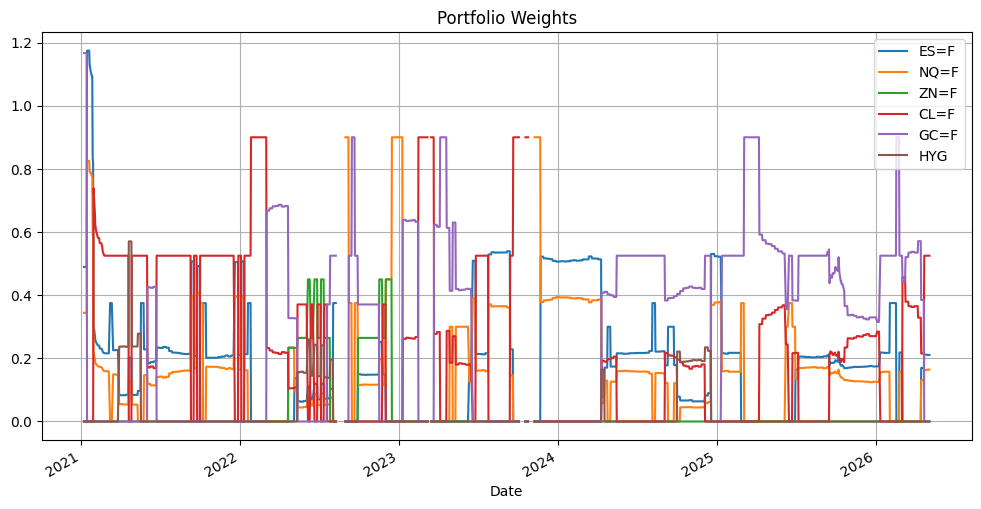

In [109]:
# ============================================================
# Dynamic Macro Portfolio
# ============================================================
#
# Features:
# - Multi-horizon momentum ensemble
# - Trend persistence filter
# - Hysteresis / deadband filtering
# - Inverse volatility scaling
# - Macro regime conditioning
# - Macro risk bucket allocation
# - Volatility targeting
# - Cross-asset trend regime scaling
# - No leverage gross exposure cap
#
# ============================================================

# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5
target_vol = 0.10

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

# ------------------------------------------------------------
# Hysteresis thresholds
# ------------------------------------------------------------

entry_threshold = 0.08
exit_threshold = 0.03

# ============================================================
# Momentum Ensemble Signal
# ============================================================

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1

raw_signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

# ============================================================
# Trend Persistence Filter
# ============================================================

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1

trend_filter = (
    np.sign(fast_trend)
    * (np.sign(fast_trend) == np.sign(slow_trend))
)

signal = raw_signal * trend_filter

# ============================================================
# Hysteresis / Deadband Filter
# ============================================================
#
# Purpose:
# - reduce overtrading
# - reduce false reversals
# - persist positions through minor noise
#
# Logic:
# - enter when signal > entry_threshold
# - exit when signal < exit_threshold
# - otherwise hold prior position
#
# ============================================================

filtered_signal = signal.copy() * 0.0

for col in signal.columns:
    prev_position = 0.0

    for i in range(len(signal)):
        current_signal = signal[col].iloc[i]

        # Missing values
        if pd.isna(current_signal):

            filtered_signal.loc[
                filtered_signal.index[i],
                col
            ] = prev_position

            continue

        # Strong enough to enter/reverse
        if abs(current_signal) > entry_threshold:
            prev_position = np.sign(current_signal)

        # Weak enough to exit
        elif abs(current_signal) < exit_threshold:
            prev_position = 0.0

        # Hold previous position
        filtered_signal.loc[
            filtered_signal.index[i],
            col
        ] = prev_position

signal = filtered_signal

# ============================================================
# Cross-Asset Trend Strength Regime Scaling
# ============================================================
#
# Purpose:
# - scale exposure UP during strong macro trend regimes
# - scale exposure DOWN during weak/choppy regimes
#
# ============================================================

trend_strength = signal.abs().mean(axis=1)

trend_strength_baseline = (
    trend_strength
    .rolling(252)
    .mean()
)

regime_scalar = (
    trend_strength
    / trend_strength_baseline
)

regime_scalar = regime_scalar.clip(
    lower=0.25,
    upper=1.0
)

regime_scalar = regime_scalar.fillna(1.0)

# ============================================================
# Inverse Volatility Scaling
# ============================================================
rolling_vol = (
    returns
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

rolling_vol = rolling_vol.clip(lower=vol_floor)

inv_vol = 1 / rolling_vol

raw_scores = signal * inv_vol

# Remove weak/noisy exposures
if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )

else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Regime Conditioning
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()

dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

risk_multiplier = pd.Series(
    1.0,
    index=returns.index
)

# ------------------------------------------------------------
# High volatility regime
# ------------------------------------------------------------
risk_multiplier[vix > vix_ma * 1.25] *= 0.75

# ------------------------------------------------------------
# Strong dollar = tighter liquidity
# ------------------------------------------------------------
risk_multiplier[dxy_mom > 0.03] *= 0.85

# ------------------------------------------------------------
# Falling bonds = rising yields / duration stress
# ------------------------------------------------------------
risk_multiplier[zn_mom < -0.02] *= 0.85
conditioned_scores = raw_scores.mul(
    risk_multiplier,
    axis=0
)

# ============================================================
# Macro Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["ES=F", "NQ=F", "HYG"],
    "inflation": ["CL=F", "GC=F"],
    "rates": ["ZN=F"]
}

group_target_weight = {
    "growth": 1/4,
    "inflation": 2/4,
    "rates": 1/4
}

# ============================================================
# Bucketed Weight Construction
# ============================================================

weights = pd.DataFrame(
    index=returns.index,
    columns=tradable_assets,
    dtype=float
)

for date in conditioned_scores.index:

    final_row = pd.Series(
        0.0,
        index=tradable_assets
    )

    for group_name, assets in risk_groups.items():

        group_scores = conditioned_scores.loc[
            date,
            assets
        ].copy()

        if group_scores.abs().sum() == 0:
            continue

        # Normalize within bucket
        group_weights = (
            group_scores
            / group_scores.abs().sum()
        )

        # Apply bucket allocation
        group_weights *= group_target_weight[group_name]

        final_row.loc[assets] = group_weights

    weights.loc[date] = final_row

# ============================================================
# Concentration Cap
# ============================================================

def cap_and_renormalize(
    row,
    max_abs_weight=0.35
):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Rebalance
# ============================================================

rebalance_mask = (
    np.arange(len(weights))
    % rebalance_freq
    == 0
)

weights_rebalanced = weights.copy()

weights_rebalanced[~rebalance_mask] = np.nan

weights_rebalanced = (
    weights_rebalanced
    .ffill()
    .fillna(0.0)
)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (
    weights_rebalanced.shift(1)
    * returns
).sum(axis=1)

realized_port_vol = (
    gross_port_ret_pre
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

vol_scalar = (
    target_vol
    / realized_port_vol
)

vol_scalar = (
    vol_scalar
    .clip(lower=0.0, upper=2.0)
    .fillna(0.0)
)

# ============================================================
# Combine:
# - volatility targeting
# - trend regime scaling
# ============================================================

combined_scalar = (
    vol_scalar
    * regime_scalar
)

final_weights = weights_rebalanced.mul(
    combined_scalar,
    axis=0
)

# ============================================================
# Minimum Gross Exposure Floor
# ============================================================

min_gross_exposure = 0.9
gross_exposure = (
    final_weights
    .abs()
    .sum(axis=1)
)

# Scale UP if below minimum exposure
underinvested = gross_exposure < min_gross_exposure
exposure_scalar = pd.Series(1.0, index=final_weights.index)

exposure_scalar[underinvested] = (
    min_gross_exposure
    / gross_exposure[underinvested]
)

final_weights = final_weights.mul(exposure_scalar,axis=0)

# ============================================================
# Backtest
# ============================================================

pnl = (
    final_weights.shift(1)
    * returns
)
port_ret = pnl.sum(axis=1).dropna()
cum_pnl = np.exp(port_ret.cumsum())

# ============================================================
# Metrics
# ============================================================

sharpe = (
    port_ret.mean()
    / port_ret.std()
) * np.sqrt(252)

ann_ret = port_ret.mean() * 252

ann_vol_realized = (
    port_ret.std()
    * np.sqrt(252)
)

running_max = cum_pnl.cummax()

drawdown = (
    cum_pnl
    / running_max
    - 1
)

max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))

print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Portfolio Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

## Dynamic Macro Portfolio

Sharpe: 1.01
Annualized Return: 0.104
Annualized Vol: 0.1027
Max Drawdown: -0.1453
Average Gross Leverage: 0.56


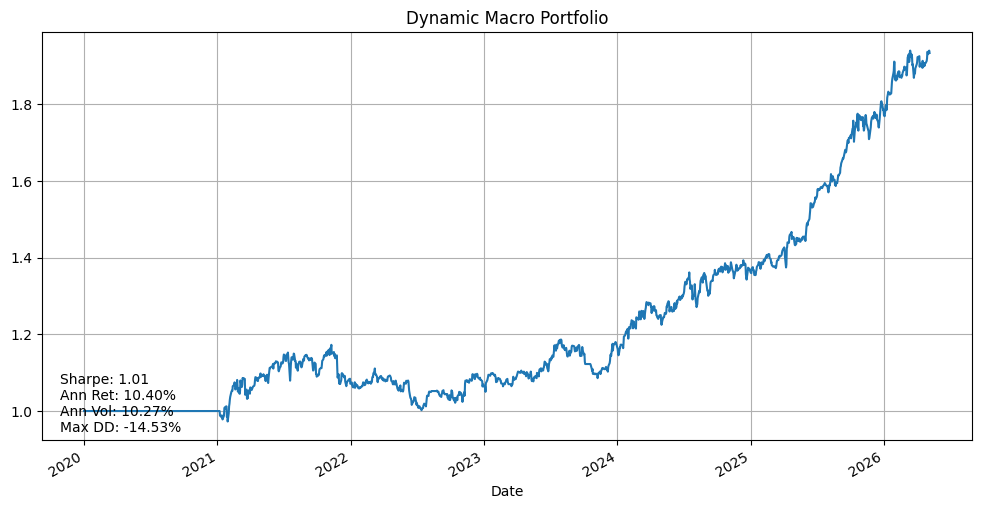

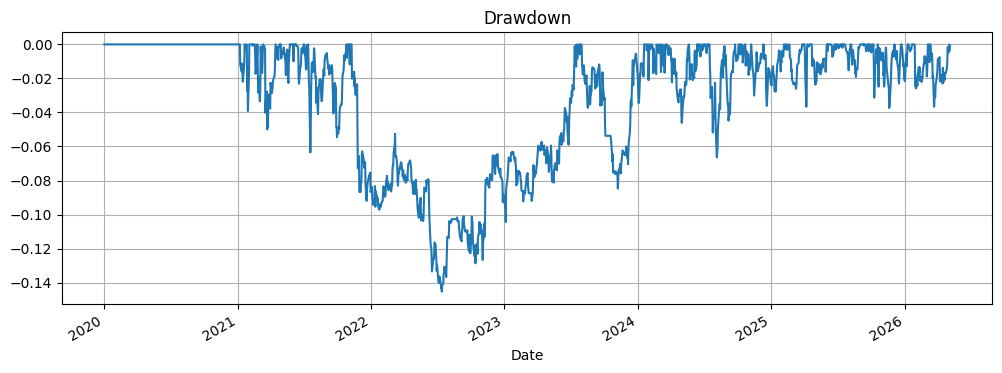

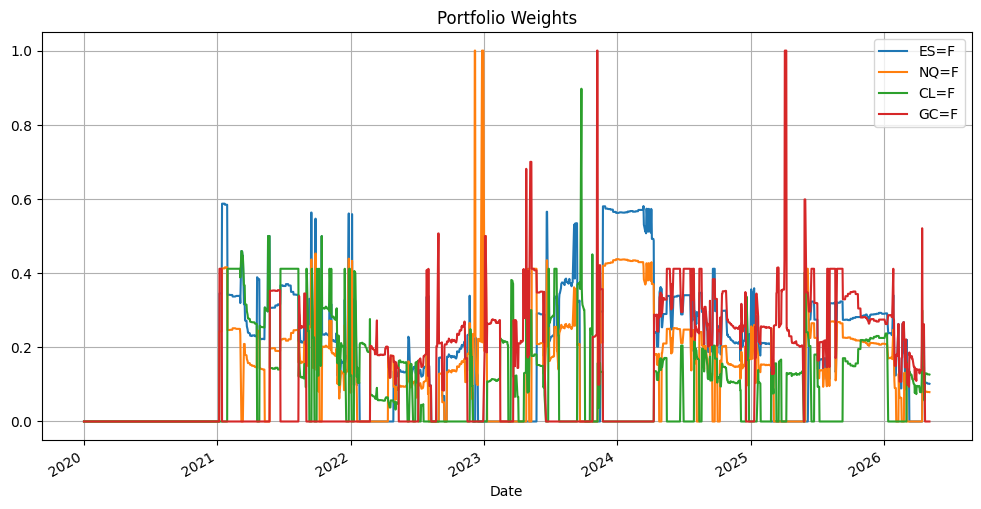

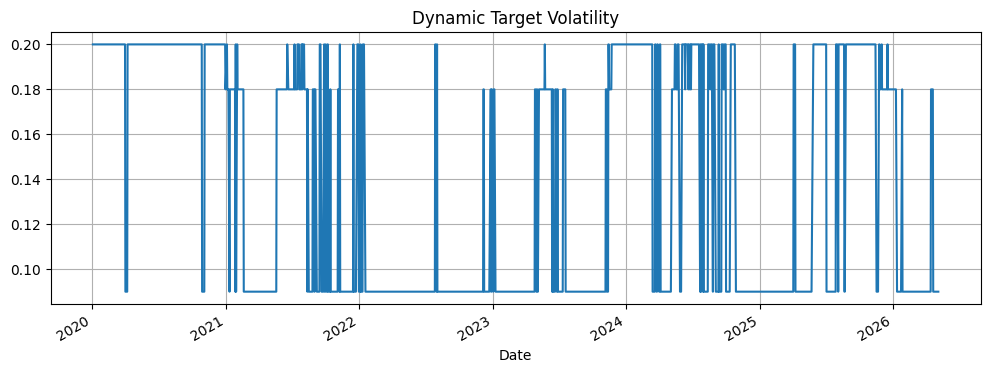

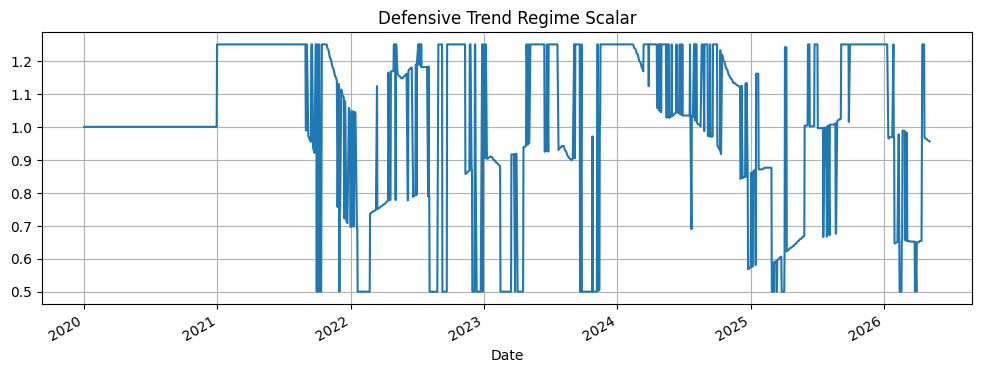

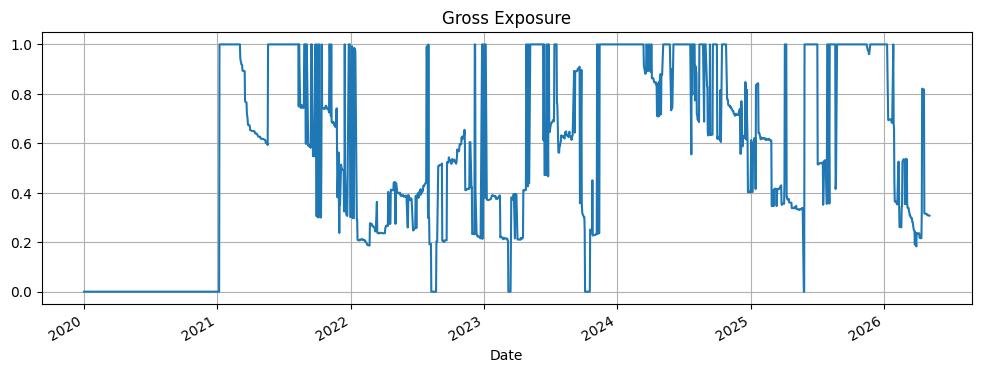

In [130]:
# ============================================================
# Dynamic Macro Portfolio
# ============================================================
#
# Features:
# - Multi-horizon momentum ensemble
# - Trend persistence filter
# - Hysteresis / deadband filtering
# - Inverse volatility scaling
# - Macro regime conditioning
# - Macro risk bucket allocation
# - Dynamic volatility targeting
# - Defensive trend regime scaling
# - No leverage gross exposure cap
#
# ============================================================

# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------
tradable_assets = [
    "ES=F",
    "NQ=F",
    # "ZN=F",
    "CL=F",
    "GC=F"
    # "HYG"
]

condition_assets = [
    "^VIX",
    "DX-Y.NYB",
    "ZN=F"
]

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5

base_target_vol = 0.20
risk_off_target_vol = 0.09
risk_on_target_vol = 0.18

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

entry_threshold = 0.05
exit_threshold = 0.03

# ============================================================
# Momentum Ensemble Signal
# ============================================================

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1

raw_signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

# ============================================================
# Trend Persistence Filter
# ============================================================

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1

trend_filter = (
    np.sign(fast_trend)
    * (np.sign(fast_trend) == np.sign(slow_trend))
)

signal = raw_signal * trend_filter

# ============================================================
# Hysteresis / Deadband Filter
# ============================================================

filtered_signal = signal.copy() * 0.0

for col in signal.columns:
    prev_position = 0.0

    for i in range(len(signal)):
        current_signal = signal[col].iloc[i]

        if pd.isna(current_signal):
            filtered_signal.loc[
                filtered_signal.index[i],
                col
            ] = prev_position
            continue

        if abs(current_signal) > entry_threshold:
            prev_position = np.sign(current_signal)

        elif abs(current_signal) < exit_threshold:
            prev_position = 0.0

        filtered_signal.loc[
            filtered_signal.index[i],
            col
        ] = prev_position

signal = filtered_signal

# ============================================================
# Cross-Asset Trend Strength
# ============================================================

trend_strength = signal.abs().mean(axis=1)

trend_strength_baseline = (
    trend_strength
    .rolling(252)
    .mean()
)

# Defensive only:
# - never increases exposure above 1.0
# - only cuts exposure in weak trend regimes
regime_scalar = (
    trend_strength
    / trend_strength_baseline
)

regime_scalar = regime_scalar.clip(
    lower=0.5,
    upper=1.25
)

regime_scalar = regime_scalar.fillna(1.0)

# ============================================================
# Inverse Volatility Scaling
# ============================================================

rolling_vol = (
    returns
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

rolling_vol = rolling_vol.clip(lower=vol_floor)

inv_vol = 1 / rolling_vol

raw_scores = signal * inv_vol

if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )
else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Regime Conditioning Inputs
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()

dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

# ============================================================
# Risk Multiplier
# ============================================================

risk_multiplier = pd.Series(1.0, index=returns.index)

risk_multiplier[vix > vix_ma * 1.25] *= 0.75
risk_multiplier[dxy_mom > 0.03] *= 0.85
risk_multiplier[zn_mom < -0.02] *= 0.85

conditioned_scores = raw_scores.mul(
    risk_multiplier,
    axis=0
)

# ============================================================
# Dynamic Target Volatility
# ============================================================
#
# This is the main new logic.
#
# Instead of always targeting 10% vol:
# - risk-off environments target 6%
# - normal environments target 10%
# - strong-trend / low-stress environments target 14%
#
# ============================================================

dynamic_target_vol = pd.Series(
    base_target_vol,
    index=returns.index
)

risk_off = (
    (vix > vix_ma * 1.25)
    | (dxy_mom > 0.03)
    | (zn_mom < -0.02)
    | (trend_strength < trend_strength_baseline)
)

strong_trend = (
    (trend_strength > trend_strength_baseline * 1.20)
    & (vix < vix_ma)
    & (dxy_mom <= 0.03)
    & (zn_mom >= -0.02)
)

dynamic_target_vol[risk_off] = risk_off_target_vol
dynamic_target_vol[strong_trend] = risk_on_target_vol

dynamic_target_vol = dynamic_target_vol.fillna(base_target_vol)

# ============================================================
# Macro Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["ES=F", "NQ=F"],
    "inflation": ["CL=F", "GC=F"]
    # "rates": ["ZN=F"]
}

group_target_weight = {
    "growth": 0.5,
    "inflation": 0.5
    # "rates": 0.3
}

# ============================================================
# Bucketed Weight Construction
# ============================================================

weights = pd.DataFrame(
    index=returns.index,
    columns=tradable_assets,
    dtype=float
)

for date in conditioned_scores.index:
    final_row = pd.Series(
        0.0,
        index=tradable_assets
    )

    for group_name, assets in risk_groups.items():
        group_scores = conditioned_scores.loc[
            date,
            assets
        ].copy()

        if group_scores.abs().sum() == 0:
            continue

        group_weights = (
            group_scores
            / group_scores.abs().sum()
        )

        group_weights *= group_target_weight[group_name]

        final_row.loc[assets] = group_weights

    weights.loc[date] = final_row

# ============================================================
# Concentration Cap
# ============================================================

def cap_and_renormalize(row, max_abs_weight=0.35):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Rebalance
# ============================================================

rebalance_mask = (
    np.arange(len(weights))
    % rebalance_freq
    == 0
)

weights_rebalanced = weights.copy()
weights_rebalanced[~rebalance_mask] = np.nan

weights_rebalanced = (
    weights_rebalanced
    .ffill()
    .fillna(0.0)
)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (
    weights_rebalanced.shift(1)
    * returns
).sum(axis=1)

realized_port_vol = (
    gross_port_ret_pre
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

vol_scalar = (
    dynamic_target_vol
    / realized_port_vol
)

vol_scalar = (
    vol_scalar
    .clip(lower=0.0, upper=2.0)
    .fillna(0.0)
)

# ============================================================
# Combine:
# - dynamic volatility targeting
# - defensive trend regime scaling
# ============================================================

combined_scalar = (
    vol_scalar
    * regime_scalar
)

final_weights = weights_rebalanced.mul(
    combined_scalar,
    axis=0
)

# ============================================================
# Gross Exposure Cap: No Leverage
# ============================================================

gross_leverage = (
    final_weights
    .abs()
    .sum(axis=1)
)

leverage_scalar = (
    max_gross_leverage
    / gross_leverage
).clip(upper=1.0).fillna(1.0)

final_weights = final_weights.mul(
    leverage_scalar,
    axis=0
)

# ============================================================
# Backtest
# ============================================================

pnl = (
    final_weights.shift(1)
    * returns
)

port_ret = pnl.sum(axis=1).dropna()
cum_pnl = np.exp(port_ret.cumsum())

# ============================================================
# Metrics
# ============================================================

sharpe = (
    port_ret.mean()
    / port_ret.std()
) * np.sqrt(252)

ann_ret = port_ret.mean() * 252

ann_vol_realized = (
    port_ret.std()
    * np.sqrt(252)
)

running_max = cum_pnl.cummax()

drawdown = (
    cum_pnl
    / running_max
    - 1
)

max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))

print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Portfolio Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

# ============================================================
# Diagnostics
# ============================================================

dynamic_target_vol.plot(
    figsize=(12, 4),
    title="Dynamic Target Volatility",
    grid=True
)
plt.show()

regime_scalar.plot(
    figsize=(12, 4),
    title="Defensive Trend Regime Scalar",
    grid=True
)
plt.show()

final_weights.abs().sum(axis=1).plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)
plt.show()

In [131]:
asset_pnl = pnl.sum()
asset_sharpe = pnl.mean() / pnl.std() * np.sqrt(252)
print(asset_pnl)
print(asset_sharpe)

ES=F    0.205231
NQ=F    0.102456
CL=F    0.168084
GC=F    0.183181
dtype: float64
ES=F    0.984110
NQ=F    0.453913
CL=F    0.451956
GC=F    0.698663
dtype: float64


In [132]:
turnover = (final_weights.diff().abs().sum(axis=1))

print(turnover.mean())

0.06762250570776553


## ETF Version

[*********************100%***********************]  7 of 7 completed


Sharpe: 1.08
Annualized Return: 0.106
Annualized Vol: 0.0978
Max Drawdown: -0.1728
Average Gross Leverage: 0.67


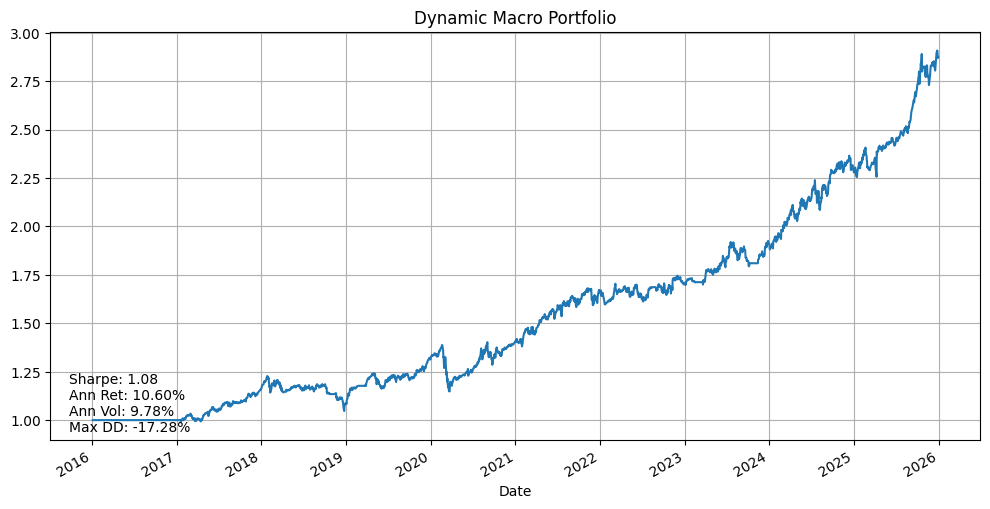

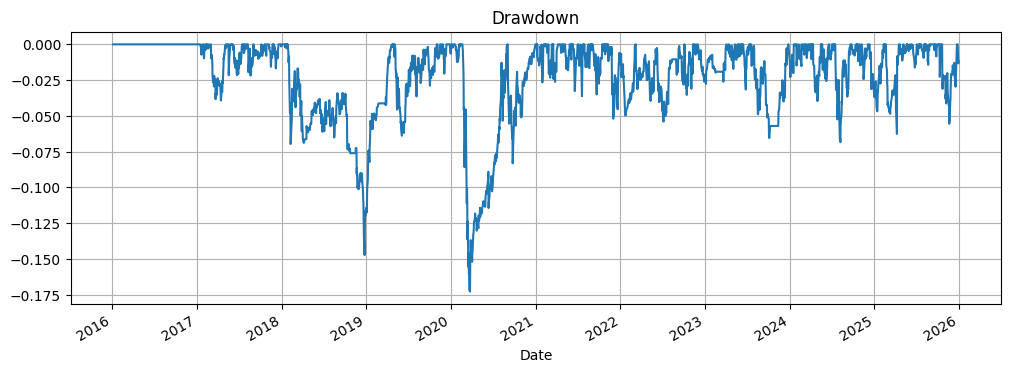

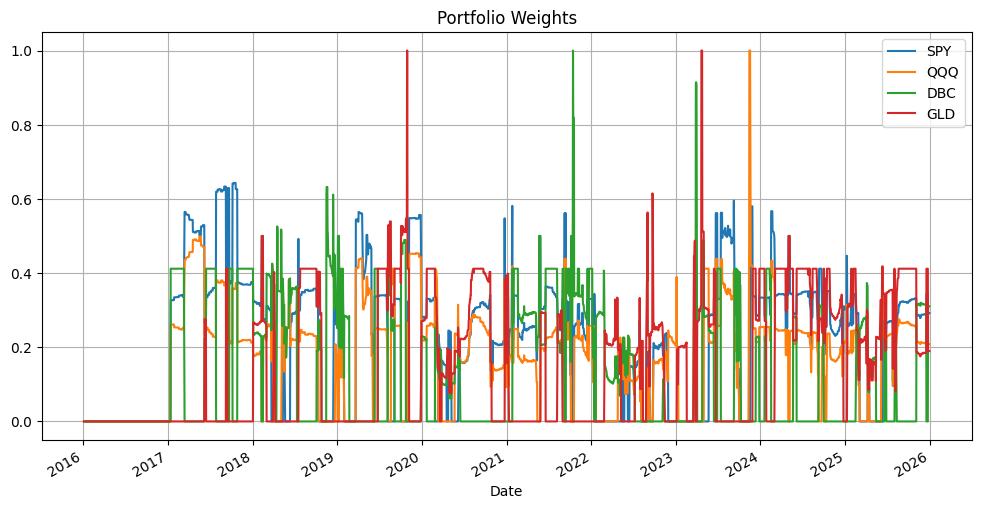

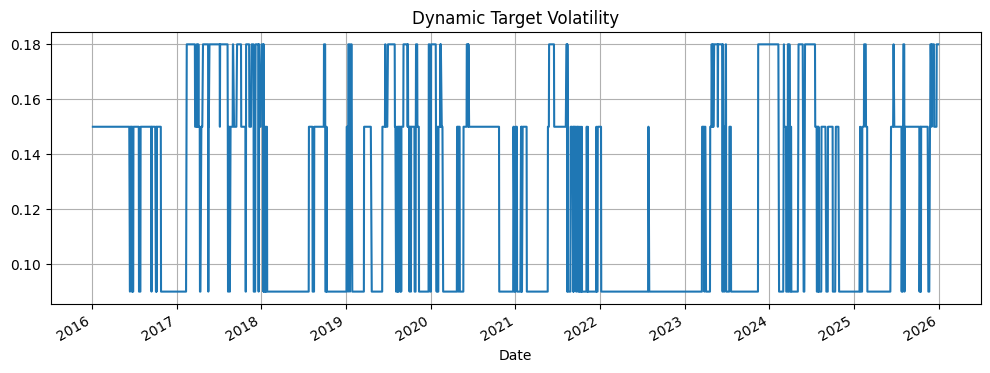

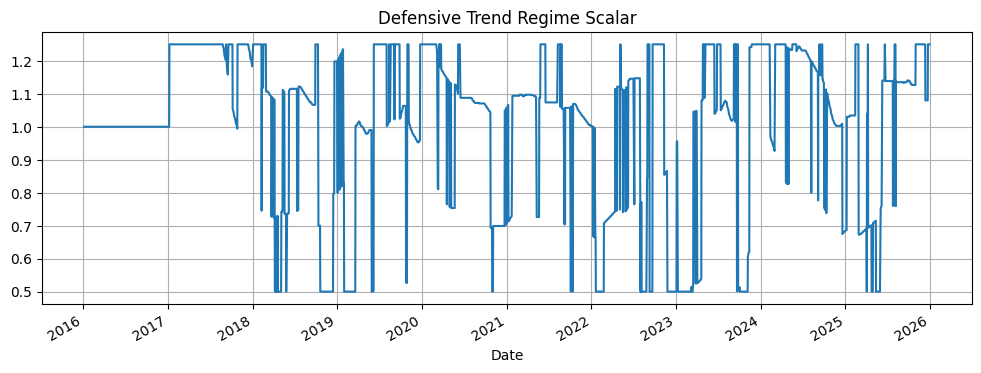

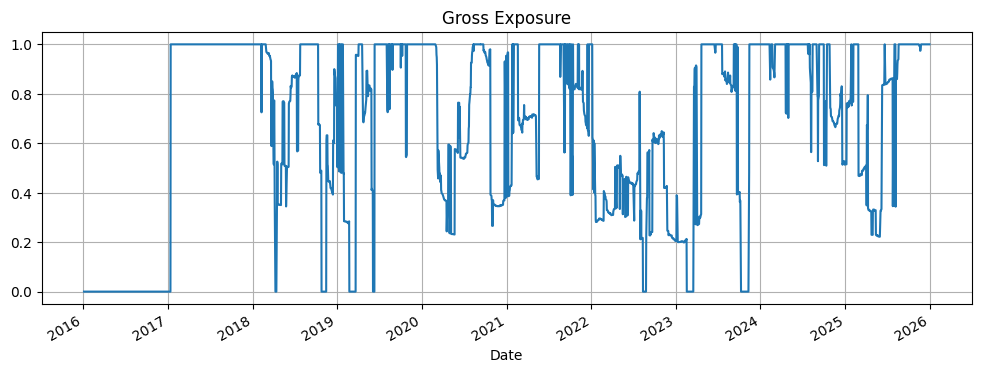

In [210]:
# ============================================================
# Dynamic Macro Portfolio
# ============================================================
#
# Features:
# - Multi-horizon momentum ensemble
# - Trend persistence filter
# - Hysteresis / deadband filtering
# - Inverse volatility scaling
# - Macro regime conditioning
# - Macro risk bucket allocation
# - Dynamic volatility targeting
# - Defensive trend regime scaling
# - No leverage gross exposure cap
#
# ============================================================
start_date = "2016-01-01"
end_date = "2025-12-31"
# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------
tradable_assets = [
    "SPY",   # broad equities
    "QQQ",   # growth / duration equities
    # "HYG",    # credit beta
    "DBC",   # broad commodities
    "GLD",   # gold / monetary stress
    # "XLE",    # energy equities
    # "TLT",   # long duration treasuries
    # "TIP"    # inflation-linked duration
]

condition_assets = [
    "^VIX",
    "DX-Y.NYB",
    "ZN=F"
]
universe = tradable_assets + condition_assets

data = yf.download(universe, start=start_date, end=end_date)
data.head()

close_df = data["Close"].dropna()
volume_df = data["Volume"]
ret_df = close_df.pct_change()
log_ret_df = np.log(close_df / close_df.shift(1))

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5

base_target_vol = 0.15
risk_off_target_vol = 0.09
risk_on_target_vol = 0.18

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

entry_threshold = 0.06
exit_threshold = 0.03

# ============================================================
# Momentum Ensemble Signal
# ============================================================

mom_3m  = prices / prices.shift(63)  - 1
mom_6m  = prices / prices.shift(126) - 1
mom_12m = prices / prices.shift(252) - 1

raw_signal = (
    0.5 * mom_3m +
    0.3 * mom_6m +
    0.2 * mom_12m
)

# ============================================================
# Trend Persistence Filter
# ============================================================

fast_trend = prices / prices.shift(63) - 1
slow_trend = prices / prices.shift(252) - 1

trend_filter = (
    np.sign(fast_trend)
    * (np.sign(fast_trend) == np.sign(slow_trend))
)

signal = raw_signal * trend_filter

# ============================================================
# Hysteresis / Deadband Filter
# ============================================================

filtered_signal = signal.copy() * 0.0

for col in signal.columns:
    prev_position = 0.0

    for i in range(len(signal)):
        current_signal = signal[col].iloc[i]

        if pd.isna(current_signal):
            filtered_signal.loc[
                filtered_signal.index[i],
                col
            ] = prev_position
            continue

        if abs(current_signal) > entry_threshold:
            prev_position = np.sign(current_signal)

        elif abs(current_signal) < exit_threshold:
            prev_position = 0.0

        filtered_signal.loc[
            filtered_signal.index[i],
            col
        ] = prev_position

signal = filtered_signal

# ============================================================
# Cross-Asset Trend Strength
# ============================================================

trend_strength = signal.abs().mean(axis=1)

trend_strength_baseline = (
    trend_strength
    .rolling(252)
    .mean()
)

# Defensive only:
# - never increases exposure above 1.0
# - only cuts exposure in weak trend regimes
regime_scalar = (
    trend_strength
    / trend_strength_baseline
)

regime_scalar = regime_scalar.clip(
    lower=0.5,
    upper=1.25
)

regime_scalar = regime_scalar.fillna(1.0)

# ============================================================
# Inverse Volatility Scaling
# ============================================================

rolling_vol = (
    returns
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

rolling_vol = rolling_vol.clip(lower=vol_floor)

inv_vol = 1 / rolling_vol

raw_scores = signal * inv_vol

if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )
else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Regime Conditioning Inputs
# ============================================================

vix = close_df["^VIX"]
dxy = close_df["DX-Y.NYB"]
zn = close_df["ZN=F"]

vix_ma = vix.rolling(90).mean()

dxy_mom = np.log(dxy / dxy.shift(60))
zn_mom = np.log(zn / zn.shift(60))

# ============================================================
# Risk Multiplier
# ============================================================

risk_multiplier = pd.Series(1.0, index=returns.index)

risk_multiplier[vix > vix_ma * 1.25] *= 0.75
risk_multiplier[dxy_mom > 0.03] *= 0.85
risk_multiplier[zn_mom < -0.02] *= 0.85

conditioned_scores = raw_scores.mul(
    risk_multiplier,
    axis=0
)

# ============================================================
# Dynamic Target Volatility
# ============================================================
#
# This is the main new logic.
#
# Instead of always targeting 10% vol:
# - risk-off environments target 6%
# - normal environments target 10%
# - strong-trend / low-stress environments target 14%
#
# ============================================================

dynamic_target_vol = pd.Series(
    base_target_vol,
    index=returns.index
)

risk_off = (
    (vix > vix_ma * 1.25)
    | (dxy_mom > 0.03)
    | (zn_mom < -0.02)
    | (trend_strength < trend_strength_baseline)
)

strong_trend = (
    (trend_strength > trend_strength_baseline * 1.20)
    & (vix < vix_ma)
    & (dxy_mom <= 0.03)
    & (zn_mom >= -0.02)
)

dynamic_target_vol[risk_off] = risk_off_target_vol
dynamic_target_vol[strong_trend] = risk_on_target_vol

dynamic_target_vol = dynamic_target_vol.fillna(base_target_vol)

# ============================================================
# Macro Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["SPY", "QQQ"],
    "inflation": ["DBC", "GLD"],
    # "rates": ["TLT", "TIP"]
    
}

group_target_weight = {
    "growth": 0.5,
    "inflation": 0.5
    # "rates": 0.3
}

# ============================================================
# Bucketed Weight Construction
# ============================================================
weights = pd.DataFrame(
    index=returns.index,
    columns=tradable_assets,
    dtype=float
)

for date in conditioned_scores.index:
    final_row = pd.Series(
        0.0,
        index=tradable_assets
    )

    for group_name, assets in risk_groups.items():
        group_scores = conditioned_scores.loc[
            date,
            assets
        ].copy()

        if group_scores.abs().sum() == 0:
            continue

        group_weights = (
            group_scores
            / group_scores.abs().sum()
        )

        group_weights *= group_target_weight[group_name]

        final_row.loc[assets] = group_weights

    weights.loc[date] = final_row

# ============================================================
# Concentration Cap
# ============================================================
def cap_and_renormalize(row, max_abs_weight=0.35):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    row = row / row.abs().sum()

    return row

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

# ============================================================
# Rebalance
# ============================================================
rebalance_mask = (
    np.arange(len(weights))
    % rebalance_freq
    == 0
)

weights_rebalanced = weights.copy()
weights_rebalanced[~rebalance_mask] = np.nan
weights_rebalanced = (
    weights_rebalanced
    .ffill()
    .fillna(0.0)
)

# ============================================================
# Volatility Targeting
# ============================================================

gross_port_ret_pre = (
    weights_rebalanced.shift(1)
    * returns
).sum(axis=1)

realized_port_vol = (
    gross_port_ret_pre
    .rolling(lookback)
    .std()
    * np.sqrt(252)
)

vol_scalar = (
    dynamic_target_vol
    / realized_port_vol
)

vol_scalar = (
    vol_scalar
    .clip(lower=0.0, upper=2.0)
    .fillna(0.0)
)

# ============================================================
# Combine:
# - dynamic volatility targeting
# - defensive trend regime scaling
# ============================================================

combined_scalar = (
    vol_scalar
    * regime_scalar
)

final_weights = weights_rebalanced.mul(
    combined_scalar,
    axis=0
)

# ============================================================
# Gross Exposure Cap: No Leverage
# ============================================================

gross_leverage = (
    final_weights
    .abs()
    .sum(axis=1)
)

leverage_scalar = (
    max_gross_leverage
    / gross_leverage
).clip(upper=1.0).fillna(1.0)

final_weights = final_weights.mul(
    leverage_scalar,
    axis=0
)

# ============================================================
# Backtest
# ============================================================

pnl = (
    final_weights.shift(1)
    * returns
)

port_ret = pnl.sum(axis=1).dropna()
cum_pnl = np.exp(port_ret.cumsum())

# ============================================================
# Metrics
# ============================================================

sharpe = (
    port_ret.mean()
    / port_ret.std()
) * np.sqrt(252)

ann_ret = port_ret.mean() * 252

ann_vol_realized = (
    port_ret.std()
    * np.sqrt(252)
)

running_max = cum_pnl.cummax()

drawdown = (
    cum_pnl
    / running_max
    - 1
)

max_dd = drawdown.min()

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))

print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

# ============================================================
# Equity Curve
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

# ============================================================
# Drawdown
# ============================================================

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

# ============================================================
# Portfolio Weights
# ============================================================

final_weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

# ============================================================
# Diagnostics
# ============================================================

dynamic_target_vol.plot(
    figsize=(12, 4),
    title="Dynamic Target Volatility",
    grid=True
)
plt.show()

regime_scalar.plot(
    figsize=(12, 4),
    title="Defensive Trend Regime Scalar",
    grid=True
)
plt.show()

final_weights.abs().sum(axis=1).plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)
plt.show()

In [211]:
asset_pnl = pnl.sum()
asset_sharpe = pnl.mean() / pnl.std() * np.sqrt(252)
print(asset_pnl)
print(asset_sharpe)

turnover = (final_weights.diff().abs().sum(axis=1))

print(turnover.mean())

SPY    0.405189
QQQ    0.281264
DBC    0.133331
GLD    0.235670
dtype: float64
SPY    1.086983
QQQ    0.688440
DBC    0.371609
GLD    0.642506
dtype: float64
0.0537547396188232


[*********************100%***********************]  7 of 7 completed


Sharpe: 1.13
Annualized Return: 0.1158
Annualized Vol: 0.1022
Max Drawdown: -0.1272
Average Gross Leverage: 0.56
Turnover: 0.07539308277238799

PnL
SPY    0.206278
QQQ    0.133817
DBC    0.212931
GLD    0.138910
dtype: float64

Asset Sharpe
SPY    0.981985
QQQ    0.365033
DBC    1.186103
GLD    0.507106
dtype: float64


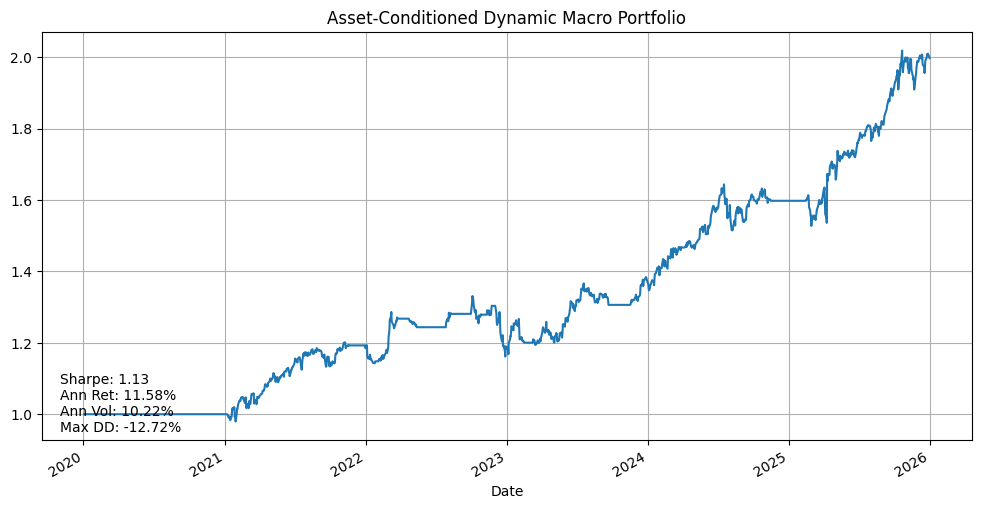

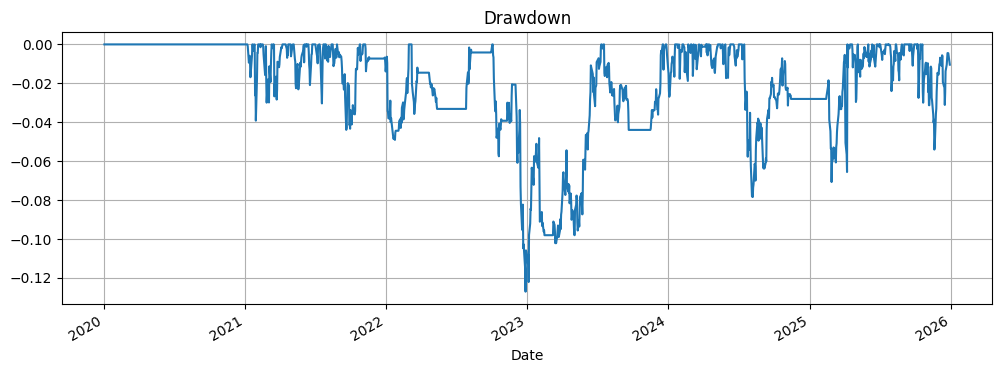

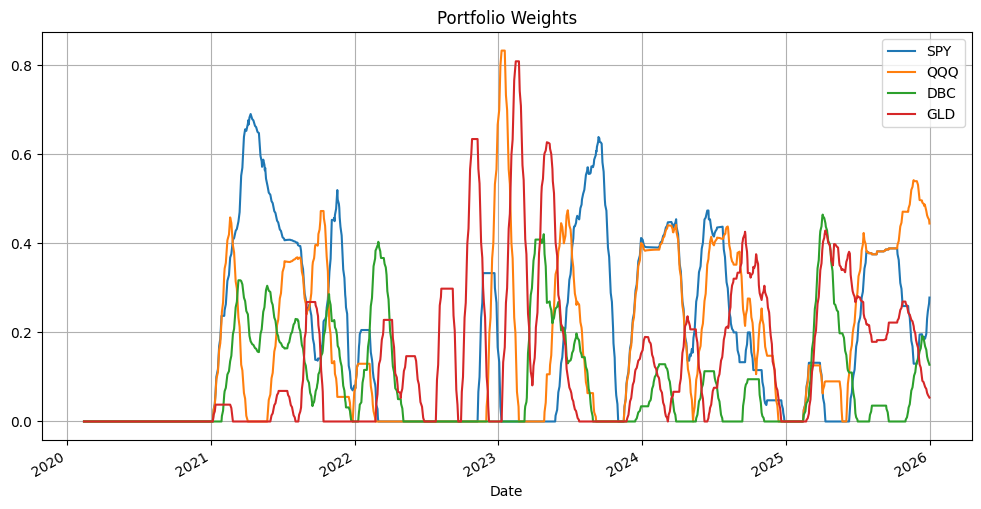

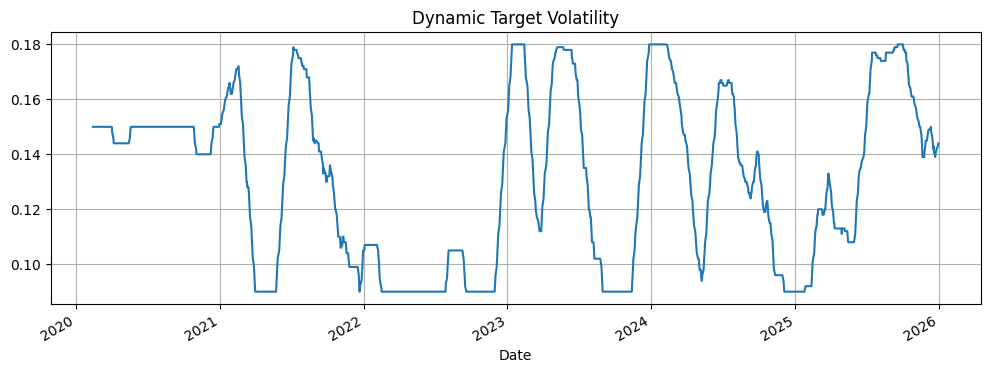

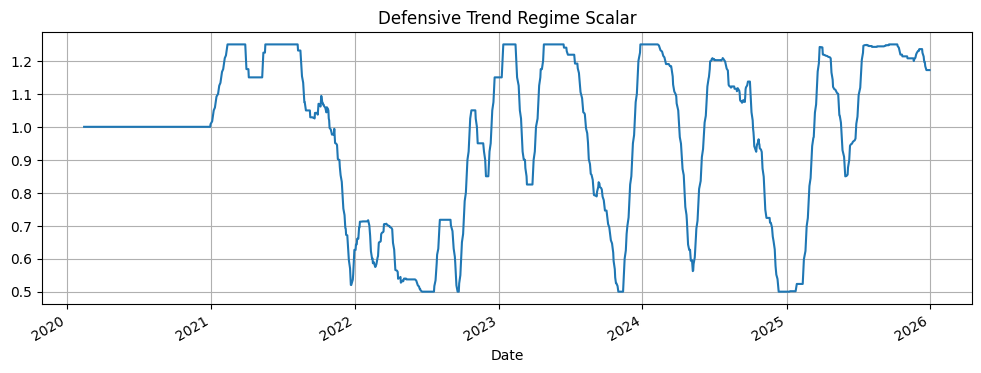

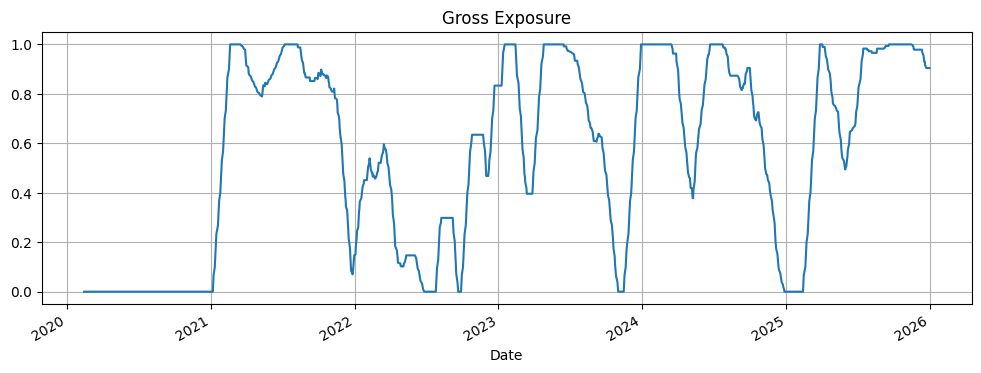

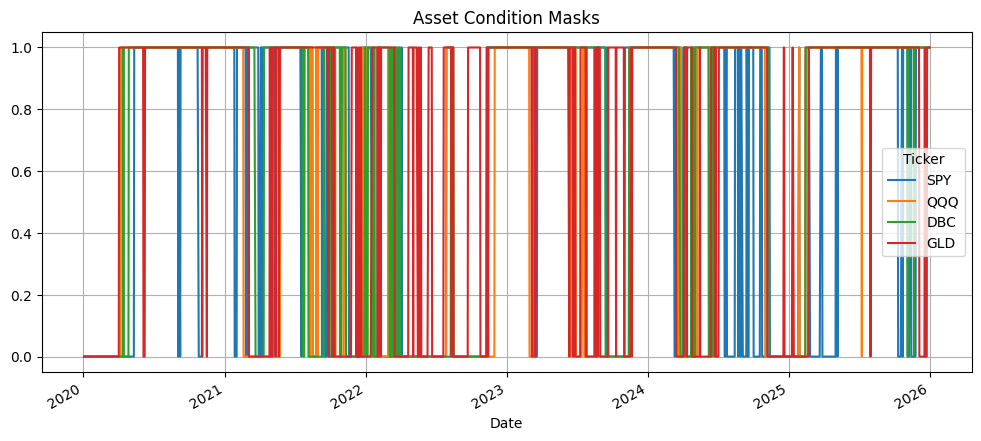

In [224]:
# ============================================================
# Asset-Conditioned Dynamic Macro Portfolio
# ============================================================
#
# Features:
# - Multi-horizon momentum ensemble
# - Trend persistence filter
# - Hysteresis / deadband filtering
# - Asset-specific macro condition filters
# - Inverse volatility scaling
# - Macro risk bucket allocation
# - Dynamic volatility targeting
# - Defensive trend regime scaling
# - No leverage gross exposure cap
#
# ============================================================

start_date = "2020-01-01"
end_date = "2025-12-31"

# ------------------------------------------------------------
# Tradable assets
# ------------------------------------------------------------

tradable_assets = [
    "SPY",
    "QQQ",
    "DBC",
    "GLD",
]

condition_assets = [
    "^VIX",
    "DX-Y.NYB",
    "ZN=F"
]

universe = tradable_assets + condition_assets

data = yf.download(
    universe,
    start=start_date,
    end=end_date
)

close_df = data["Close"].dropna()
volume_df = data["Volume"]

ret_df = close_df.pct_change()
log_ret_df = np.log(close_df / close_df.shift(1))

returns = log_ret_df[tradable_assets].dropna(how="all")
prices = close_df[tradable_assets]

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5

base_target_vol = 0.15
risk_off_target_vol = 0.09
risk_on_target_vol = 0.18

max_abs_weight = 0.35
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

vol_floor = 0.05

entry_threshold = 0.06
exit_threshold = 0.03

# ============================================================
# Helper Functions
# ============================================================

def compute_log_returns(price_df):
    return np.log(price_df / price_df.shift(1))


def compute_momentum_ensemble(price_df):
    mom_3m = price_df / price_df.shift(63) - 1
    mom_6m = price_df / price_df.shift(126) - 1
    mom_12m = price_df / price_df.shift(252) - 1

    return (
        0.5 * mom_3m
        + 0.3 * mom_6m
        + 0.2 * mom_12m
    )


def apply_trend_persistence(raw_signal, price_df):
    fast_trend = price_df / price_df.shift(63) - 1
    slow_trend = price_df / price_df.shift(252) - 1

    trend_filter = (
        np.sign(fast_trend)
        * (np.sign(fast_trend) == np.sign(slow_trend))
    )

    return raw_signal * trend_filter


def apply_hysteresis(signal_df, entry_threshold, exit_threshold):
    filtered_signal = signal_df.copy() * 0.0

    for col in signal_df.columns:
        prev_position = 0.0

        for i in range(len(signal_df)):
            current_signal = signal_df[col].iloc[i]

            if pd.isna(current_signal):
                filtered_signal.loc[
                    filtered_signal.index[i],
                    col
                ] = prev_position
                continue

            if abs(current_signal) > entry_threshold:
                prev_position = np.sign(current_signal)

            elif abs(current_signal) < exit_threshold:
                prev_position = 0.0

            filtered_signal.loc[
                filtered_signal.index[i],
                col
            ] = prev_position

    return filtered_signal


def compute_condition_features(close_df, returns_index):
    vix = close_df["^VIX"].reindex(returns_index).ffill()
    dxy = close_df["DX-Y.NYB"].reindex(returns_index).ffill()
    zn = close_df["ZN=F"].reindex(returns_index).ffill()

    vix_ma = vix.rolling(90).mean()

    dxy_trend_3m = np.log(dxy / dxy.shift(63))
    dxy_trend_6m = np.log(dxy / dxy.shift(126))

    zn_trend_3m = np.log(zn / zn.shift(63))
    zn_trend_6m = np.log(zn / zn.shift(126))

    return {
        "vix": vix,
        "vix_ma": vix_ma,
        "dxy_trend_3m": dxy_trend_3m,
        "dxy_trend_6m": dxy_trend_6m,
        "zn_trend_3m": zn_trend_3m,
        "zn_trend_6m": zn_trend_6m,
    }


def build_asset_condition_mask(prices, features):
    condition_mask = pd.DataFrame(
        True,
        index=prices.index,
        columns=prices.columns
    )

    vix = features["vix"]
    vix_ma = features["vix_ma"]

    dxy_trend_3m = features["dxy_trend_3m"]
    dxy_trend_6m = features["dxy_trend_6m"]

    zn_trend_3m = features["zn_trend_3m"]
    zn_trend_6m = features["zn_trend_6m"]

    # --------------------------------------------------------
    # Asset-specific conditions
    # --------------------------------------------------------
    #
    # SPY:
    # - favors low/falling volatility
    # - avoids strong dollar tightening
    #
    # QQQ:
    # - favors stable/falling yield pressure
    # - avoids strong dollar tightening
    #
    # DBC:
    # - favors weak/neutral dollar
    # - trend itself must be positive from main signal
    #
    # GLD:
    # - favors falling yields OR elevated volatility stress
    #
    # --------------------------------------------------------

    if "SPY" in condition_mask.columns:
        condition_mask["SPY"] = (
            (vix < vix_ma * 1.10)
            & (dxy_trend_3m < 0.03)
        )

    if "QQQ" in condition_mask.columns:
        condition_mask["QQQ"] = (
            (zn_trend_3m > -0.02)
            & (dxy_trend_3m < 0.03)
        )

    if "DBC" in condition_mask.columns:
        condition_mask["DBC"] = (
            dxy_trend_3m < 0.02
        )

    if "GLD" in condition_mask.columns:
        condition_mask["GLD"] = (
            (zn_trend_3m > 0.00)
            | (vix > vix_ma * 1.10)
            | (dxy_trend_3m < 0.00)
        )

    return condition_mask


def apply_inverse_vol_scaling(signal_df, returns, lookback, vol_floor):
    rolling_vol = (
        returns
        .rolling(lookback)
        .std()
        * np.sqrt(252)
    )

    rolling_vol = rolling_vol.clip(lower=vol_floor)

    return signal_df * (1 / rolling_vol)


def compute_trend_regime_scalar(signal_df):
    trend_strength = signal_df.abs().mean(axis=1)

    trend_strength_baseline = (
        trend_strength
        .rolling(252)
        .mean()
    )

    regime_scalar = (
        trend_strength
        / trend_strength_baseline
    )

    regime_scalar = regime_scalar.clip(
        lower=0.5,
        upper=1.25
    )

    return regime_scalar.fillna(1.0), trend_strength, trend_strength_baseline


def compute_dynamic_target_vol(
    returns_index,
    features,
    trend_strength,
    trend_strength_baseline,
    base_target_vol,
    risk_off_target_vol,
    risk_on_target_vol
):
    vix = features["vix"]
    vix_ma = features["vix_ma"]
    dxy_trend_3m = features["dxy_trend_3m"]
    zn_trend_3m = features["zn_trend_3m"]

    dynamic_target_vol = pd.Series(
        base_target_vol,
        index=returns_index
    )

    risk_off = (
        (vix > vix_ma * 1.25)
        | (dxy_trend_3m > 0.03)
        | (zn_trend_3m < -0.02)
        | (trend_strength < trend_strength_baseline)
    )

    strong_trend = (
        (trend_strength > trend_strength_baseline * 1.20)
        & (vix < vix_ma)
        & (dxy_trend_3m <= 0.03)
        & (zn_trend_3m >= -0.02)
    )

    dynamic_target_vol[risk_off] = risk_off_target_vol
    dynamic_target_vol[strong_trend] = risk_on_target_vol

    return dynamic_target_vol.fillna(base_target_vol)


def build_bucketed_weights(scores, risk_groups, group_target_weight, tradable_assets):
    weights = pd.DataFrame(
        index=scores.index,
        columns=tradable_assets,
        dtype=float
    )

    for date in scores.index:
        final_row = pd.Series(
            0.0,
            index=tradable_assets
        )

        for group_name, assets in risk_groups.items():
            group_scores = scores.loc[date, assets].copy()

            if group_scores.abs().sum() == 0:
                continue

            group_weights = (group_scores / group_scores.abs().sum())
            group_weights *= group_target_weight[group_name]

            final_row.loc[assets] = group_weights

        weights.loc[date] = final_row

    return weights


def cap_and_renormalize(row, max_abs_weight):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    return row / row.abs().sum()


def apply_rebalance(weights, rebalance_freq):
    rebalance_mask = (
        np.arange(len(weights))
        % rebalance_freq
        == 0
    )

    weights_rebalanced = weights.copy()
    weights_rebalanced[~rebalance_mask] = np.nan

    return (
        weights_rebalanced
        .ffill()
        .fillna(0.0)
    )


def apply_vol_targeting(
    weights,
    returns,
    dynamic_target_vol,
    regime_scalar,
    lookback
):
    gross_port_ret_pre = (
        weights.shift(1)
        * returns
    ).sum(axis=1)

    realized_port_vol = (
        gross_port_ret_pre
        .rolling(lookback)
        .std()
        * np.sqrt(252)
    )

    vol_scalar = (
        dynamic_target_vol
        / realized_port_vol
    )

    vol_scalar = (
        vol_scalar
        .clip(lower=0.0, upper=2.0)
        .fillna(0.0)
    )

    combined_scalar = (
        vol_scalar
        * regime_scalar
    )

    return weights.mul(
        combined_scalar,
        axis=0
    )


def apply_gross_leverage_cap(weights, max_gross_leverage):
    gross_leverage = (
        weights
        .abs()
        .sum(axis=1)
    )

    leverage_scalar = (
        max_gross_leverage
        / gross_leverage
    ).clip(upper=1.0).fillna(1.0)

    return weights.mul(
        leverage_scalar,
        axis=0
    )


def compute_performance(final_weights, returns):
    pnl = final_weights.shift(1) * returns
    port_ret = pnl.sum(axis=1).dropna()
    cum_pnl = np.exp(port_ret.cumsum())

    sharpe = (
        port_ret.mean()
        / port_ret.std()
    ) * np.sqrt(252)

    ann_ret = port_ret.mean() * 252
    ann_vol = port_ret.std() * np.sqrt(252)

    drawdown = cum_pnl / cum_pnl.cummax() - 1
    max_dd = drawdown.min()

    return {
        "pnl": pnl,
        "port_ret": port_ret,
        "cum_pnl": cum_pnl,
        "drawdown": drawdown,
        "sharpe": sharpe,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "max_dd": max_dd
    }


# ============================================================
# Signal Engine
# ============================================================

raw_signal = compute_momentum_ensemble(prices)

signal = apply_trend_persistence(
    raw_signal,
    prices
)

signal = apply_hysteresis(
    signal,
    entry_threshold,
    exit_threshold
)

# ============================================================
# Asset-Specific Conditions
# ============================================================

features = compute_condition_features(
    close_df,
    returns.index
)

condition_mask = build_asset_condition_mask(
    prices.reindex(returns.index),
    features
)

signal = signal.reindex(returns.index)

conditioned_signal = signal.where(
    condition_mask,
    0.0
)

# ============================================================
# Trend Strength / Dynamic Vol
# ============================================================

regime_scalar, trend_strength, trend_strength_baseline = (
    compute_trend_regime_scalar(conditioned_signal)
)

dynamic_target_vol = compute_dynamic_target_vol(
    returns.index,
    features,
    trend_strength,
    trend_strength_baseline,
    base_target_vol,
    risk_off_target_vol,
    risk_on_target_vol
)

# ============================================================
# Inverse Vol Scores
# ============================================================

raw_scores = apply_inverse_vol_scaling(
    conditioned_signal,
    returns,
    lookback,
    vol_floor
)

if allow_short:
    raw_scores = raw_scores.where(
        raw_scores.abs() > min_signal,
        0.0
    )
else:
    raw_scores = raw_scores.where(
        raw_scores > min_signal,
        0.0
    )

# ============================================================
# Risk Buckets
# ============================================================

risk_groups = {
    "growth": ["SPY", "QQQ"],
    "inflation": ["DBC", "GLD"],
}

group_target_weight = {
    "growth": 0.8,
    "inflation": 0.2
}

# ============================================================
# Weight Construction
# ============================================================

weights = build_bucketed_weights(
    raw_scores,
    risk_groups,
    group_target_weight,
    tradable_assets
)

weights = weights.apply(
    cap_and_renormalize,
    axis=1,
    max_abs_weight=max_abs_weight
)

weights_rebalanced = apply_rebalance(
    weights,
    rebalance_freq
)

final_weights = apply_vol_targeting(
    weights_rebalanced,
    returns,
    dynamic_target_vol,
    regime_scalar,
    lookback
)

final_weights = apply_gross_leverage_cap(
    final_weights,
    max_gross_leverage
)

# ============================================================
# Backtest
# ============================================================

perf = compute_performance(
    final_weights,
    returns
)

pnl = perf["pnl"]
port_ret = perf["port_ret"]
cum_pnl = perf["cum_pnl"]
drawdown = perf["drawdown"]

sharpe = perf["sharpe"]
ann_ret = perf["ann_ret"]
ann_vol_realized = perf["ann_vol"]
max_dd = perf["max_dd"]

print("Sharpe:", round(sharpe, 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol_realized, 4))
print("Max Drawdown:", round(max_dd, 4))

print(
    "Average Gross Leverage:",
    round(final_weights.abs().sum(axis=1).mean(), 2)
)

print(
    "Turnover:",
    final_weights.diff().abs().sum(axis=1).mean()
)

print("\nPnL")
print(pnl.sum())

print("\nAsset Sharpe")
print(
    pnl.mean()
    / pnl.std()
    * np.sqrt(252)
)

# ============================================================
# Charts
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Asset-Conditioned Dynamic Macro Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol_realized:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

final_weights.rolling(30).mean().plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

dynamic_target_vol.rolling(30).mean().plot(
    figsize=(12, 4),
    title="Dynamic Target Volatility",
    grid=True
)

plt.show()

regime_scalar.rolling(30).mean().plot(
    figsize=(12, 4),
    title="Defensive Trend Regime Scalar",
    grid=True
)

plt.show()

final_weights.abs().sum(axis=1).rolling(30).mean().plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)

plt.show()

condition_mask.astype(int).plot(
    figsize=(12, 5),
    title="Asset Condition Masks",
    grid=True
)

plt.show()

## Simplify

[*********************100%***********************]  4 of 4 completed


Sharpe: 0.51
SPY Sharpe: 0.76
Annualized Return: 0.0527
Annualized Vol: 0.1038
Max Drawdown: -0.2872
Average Gross Leverage: 0.83
Turnover: 0.040062673444981066

PnL
Ticker
SPY    0.054795
QQQ    0.063640
DBC    0.155109
GLD    0.042047
dtype: float64

Asset Sharpe
Ticker
SPY    0.260620
QQQ    0.269747
DBC    0.514248
GLD    0.142587
dtype: float64


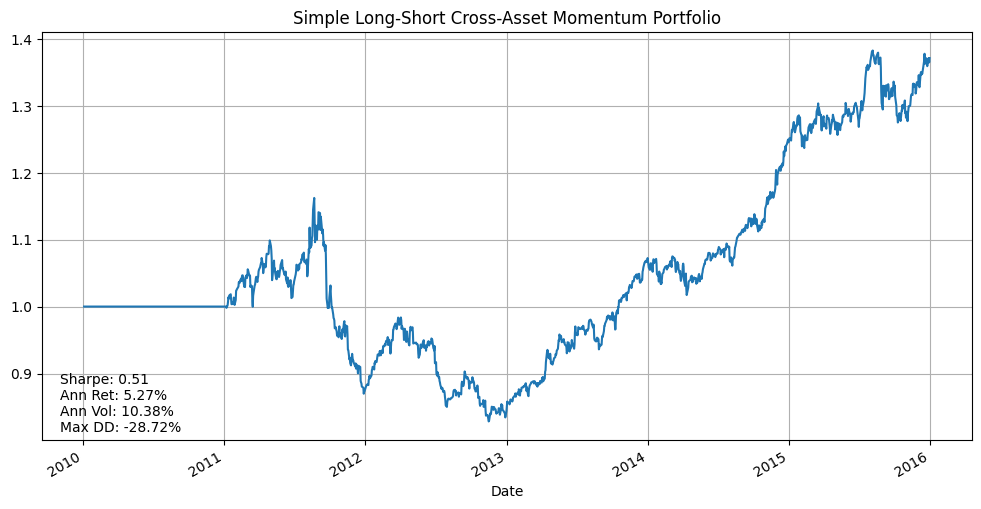

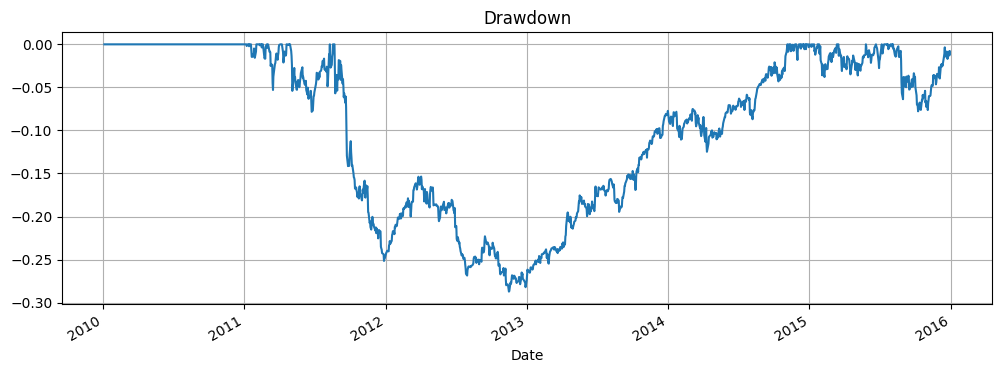

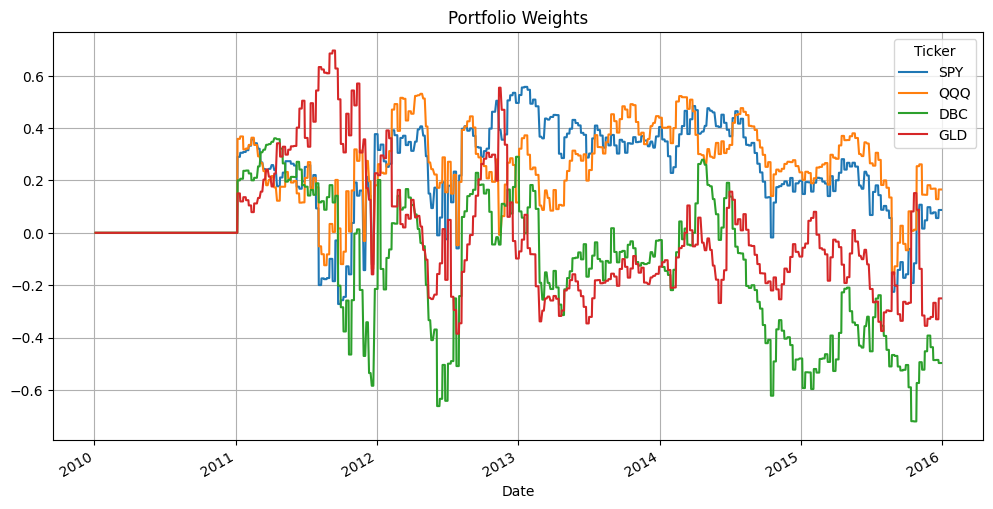

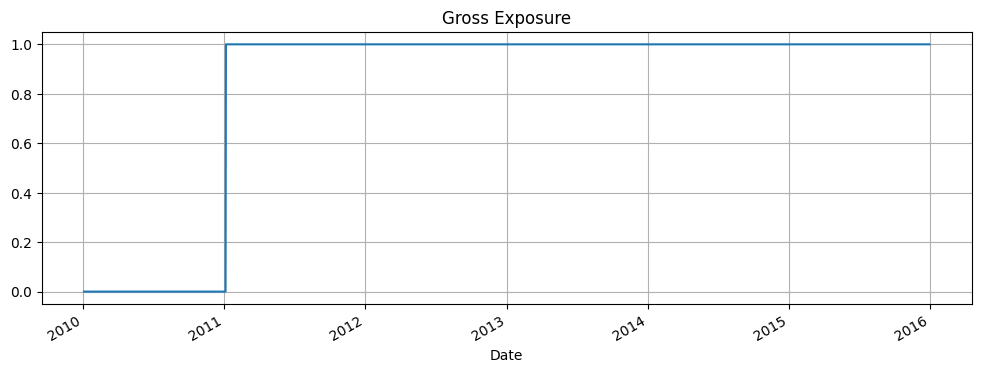

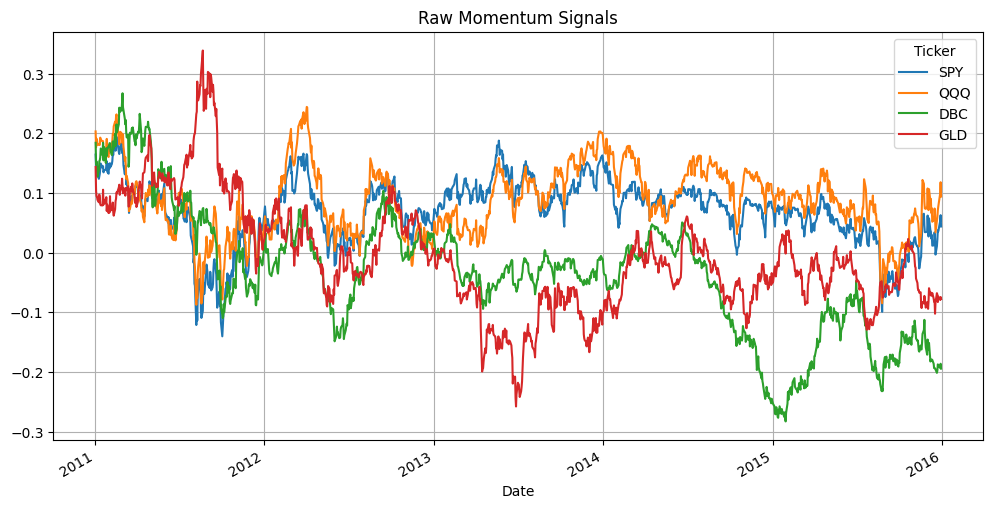

In [235]:
# ============================================================
# Simple Long-Short Cross-Asset Momentum Portfolio
# ============================================================
#
# Features:
# - Multi-horizon momentum ensemble
# - Independent asset trend streams
# - Long/short exposure allowed
# - Inverse volatility scaling
# - Capital allocated proportional to signal strength
# - Weekly rebalance
# - Gross exposure cap / no leverage
#
# Removed:
# - macro regime classifier
# - asset condition filters
# - risk buckets
# - dynamic target volatility
# - defensive trend scalar
#
# ============================================================

start_date = "2016-01-01"
end_date = "2020-12-31"

tradable_assets = [
    "SPY",
    "QQQ",
    "DBC",
    "GLD",
]

universe = tradable_assets

data = yf.download(
    universe,
    start=start_date,
    end=end_date
)

close_df = data["Close"].dropna()
prices = close_df[tradable_assets]

returns = np.log(prices / prices.shift(1))

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5

vol_floor = 0.05
max_abs_weight = 0.50
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

# ============================================================
# Helper Functions
# ============================================================

def compute_log_returns(price_df):
    return np.log(price_df / price_df.shift(1))


def compute_momentum_ensemble(price_df):
    mom_3m = price_df / price_df.shift(63) - 1
    mom_6m = price_df / price_df.shift(126) - 1
    mom_12m = price_df / price_df.shift(252) - 1

    signal = (
        0.5 * mom_3m
        + 0.3 * mom_6m
        + 0.2 * mom_12m
    )

    return signal


def apply_inverse_vol_scaling(signal_df, returns, lookback, vol_floor):
    realized_vol = (
        returns
        .rolling(lookback)
        .std()
        * np.sqrt(252)
    )

    realized_vol = realized_vol.clip(lower=vol_floor)

    scores = signal_df / realized_vol

    return scores


def clean_scores(scores, allow_short=True, min_signal=0.00):
    if allow_short:
        return scores.where(
            scores.abs() > min_signal,
            0.0
        )

    return scores.where(
        scores > min_signal,
        0.0
    )


def normalize_scores_to_weights(scores):
    gross_signal = scores.abs().sum(axis=1)

    weights = scores.div(
        gross_signal,
        axis=0
    )

    return weights.fillna(0.0)


def cap_and_renormalize(row, max_abs_weight):
    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    if row.abs().sum() == 0:
        return row

    return row / row.abs().sum()


def apply_weight_caps(weights, max_abs_weight):
    return weights.apply(
        cap_and_renormalize,
        axis=1,
        max_abs_weight=max_abs_weight
    )


def apply_rebalance(weights, rebalance_freq):
    rebalance_mask = (
        np.arange(len(weights))
        % rebalance_freq
        == 0
    )

    weights_rebalanced = weights.copy()
    weights_rebalanced[~rebalance_mask] = np.nan

    return (
        weights_rebalanced
        .ffill()
        .fillna(0.0)
    )


def apply_gross_leverage_cap(weights, max_gross_leverage):
    gross_leverage = (
        weights
        .abs()
        .sum(axis=1)
    )

    leverage_scalar = (
        max_gross_leverage
        / gross_leverage
    ).clip(upper=1.0).fillna(1.0)

    return weights.mul(
        leverage_scalar,
        axis=0
    )


def compute_performance(weights, returns):
    pnl = weights.shift(1) * returns
    port_ret = pnl.sum(axis=1).dropna()

    cum_pnl = np.exp(port_ret.cumsum())

    sharpe = (
        port_ret.mean()
        / port_ret.std()
    ) * np.sqrt(252)

    ann_ret = port_ret.mean() * 252
    ann_vol = port_ret.std() * np.sqrt(252)

    drawdown = cum_pnl / cum_pnl.cummax() - 1
    max_dd = drawdown.min()

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .mean()
    )

    asset_pnl = pnl.sum()

    asset_sharpe = (
        pnl.mean()
        / pnl.std()
        * np.sqrt(252)
    )

    return {
        "pnl": pnl,
        "port_ret": port_ret,
        "cum_pnl": cum_pnl,
        "drawdown": drawdown,
        "sharpe": sharpe,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "max_dd": max_dd,
        "turnover": turnover,
        "asset_pnl": asset_pnl,
        "asset_sharpe": asset_sharpe,
    }


# ============================================================
# Signal Construction
# ============================================================

signal = compute_momentum_ensemble(prices)

scores = apply_inverse_vol_scaling(
    signal,
    returns,
    lookback,
    vol_floor
)

scores = clean_scores(
    scores,
    allow_short=allow_short,
    min_signal=min_signal
)

# ============================================================
# Weight Construction
# ============================================================

weights = normalize_scores_to_weights(scores)

weights = apply_weight_caps(
    weights,
    max_abs_weight=max_abs_weight
)

weights = apply_rebalance(
    weights,
    rebalance_freq=rebalance_freq
)

weights = apply_gross_leverage_cap(
    weights,
    max_gross_leverage=max_gross_leverage
)

# ============================================================
# Backtest
# ============================================================

perf = compute_performance(
    weights,
    returns
)

pnl = perf["pnl"]
port_ret = perf["port_ret"]
cum_pnl = perf["cum_pnl"]
drawdown = perf["drawdown"]

sharpe = perf["sharpe"]
ann_ret = perf["ann_ret"]
ann_vol = perf["ann_vol"]
max_dd = perf["max_dd"]
turnover = perf["turnover"]

# ============================================================
# Results
# ============================================================

print("Sharpe:", round(sharpe, 2))
print("SPY Sharpe:", round(returns.dropna()['SPY'].mean() / returns.dropna()['SPY'].std() * np.sqrt(252), 2))
print("Annualized Return:", round(ann_ret, 4))
print("Annualized Vol:", round(ann_vol, 4))
print("Max Drawdown:", round(max_dd, 4))
print("Average Gross Leverage:", round(weights.abs().sum(axis=1).mean(), 2))
print("Turnover:", turnover)

print("\nPnL")
print(perf["asset_pnl"])

print("\nAsset Sharpe")
print(perf["asset_sharpe"])

# ============================================================
# Charts
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Simple Long-Short Cross-Asset Momentum Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

weights.abs().sum(axis=1).plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)

plt.show()

signal.plot(
    figsize=(12, 6),
    title="Raw Momentum Signals",
    grid=True
)

plt.show()

In [233]:
returns.dropna()['SPY'].mean() / returns.dropna()['SPY'].std() * np.sqrt(252)

np.float64(0.7525443075144472)

In [229]:
prices['SPY'].mean() / prices['SPY'].std() * np.sqrt(252)

np.float64(86.534749110425)

## Relative Momentum

[*********************100%***********************]  20 of 20 completed


spy_sharpe: 0.7525443075144472
Sharpe: 0.42
SPY Sharpe: 0.75
Annualized Return: 0.0431
Annualized Vol: 0.1025
Max Drawdown: -0.1169
Average Gross Leverage: 0.8
Turnover: 0.05732394254276851

PnL
Ticker
SPY    0.008578
QQQ    0.048476
GLD    0.007537
DBC   -0.012246
IWM    0.035704
EFA    0.019430
EEM    0.030353
DBA   -0.010319
GCC   -0.000333
UNG    0.047800
UUP    0.004419
TLT   -0.008810
IEF    0.016448
SHY    0.001015
XLE    0.002208
XLK    0.054126
XLF    0.000334
XLU   -0.041909
HYG   -0.002920
LQD    0.015140
dtype: float64

Asset Sharpe
Ticker
SPY    0.144383
QQQ    0.415530
GLD    0.115648
DBC   -0.179391
IWM    0.666186
EFA    0.535580
EEM    0.578454
DBA   -0.300247
GCC   -0.007871
UNG    0.191056
UUP    0.162133
TLT   -0.156120
IEF    0.474951
SHY    0.889945
XLE    0.019772
XLK    0.526409
XLF    0.006203
XLU   -0.861089
HYG   -0.191282
LQD    0.282110
dtype: float64


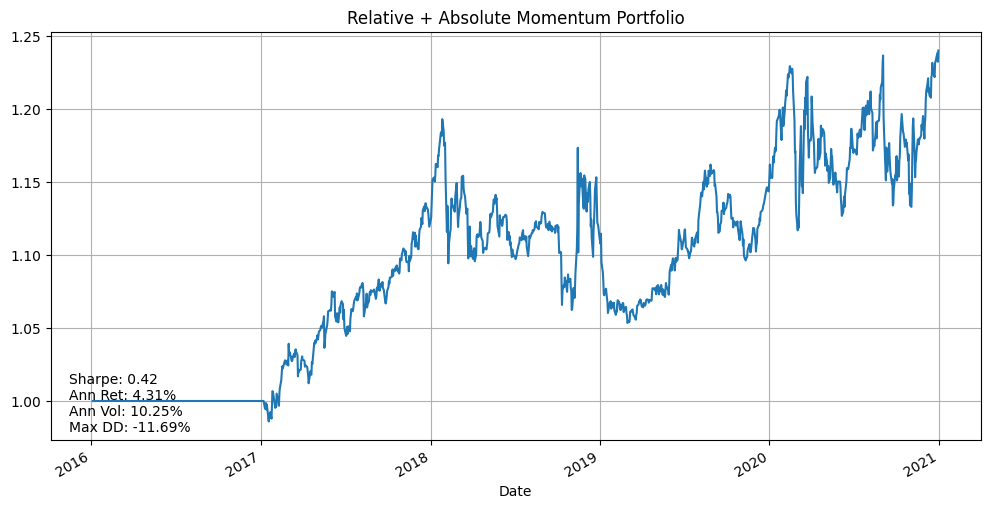

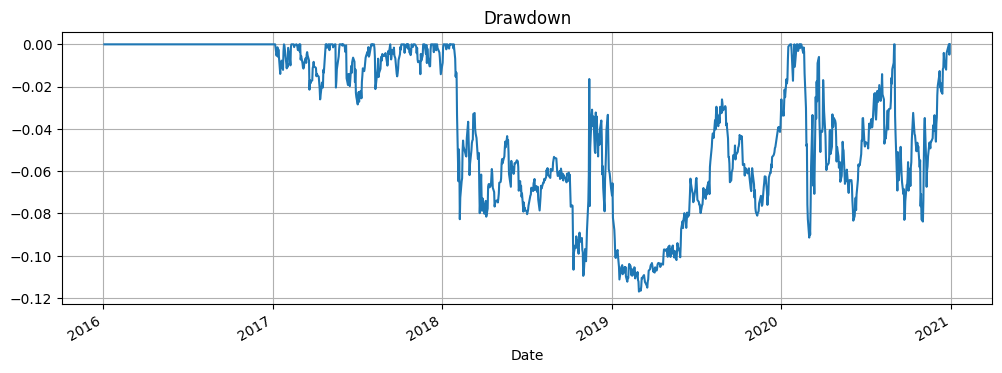

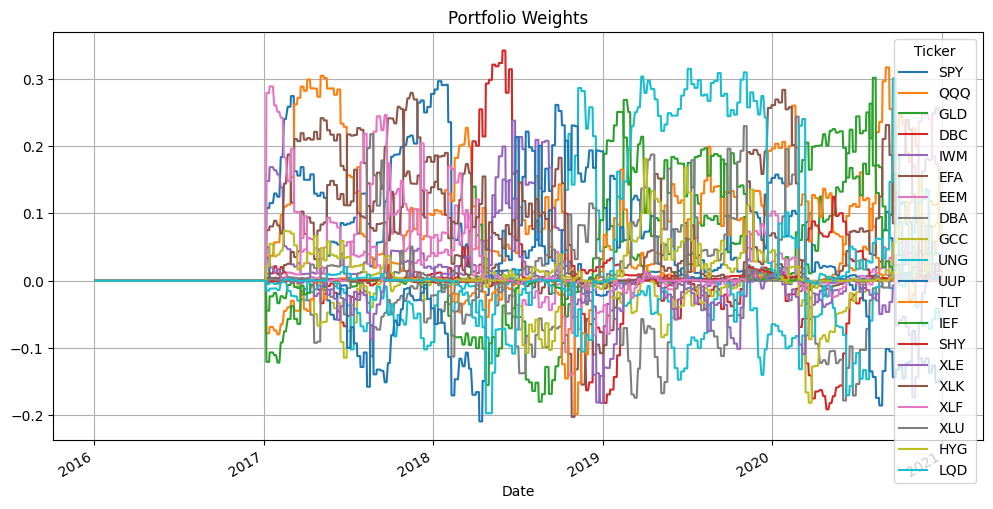

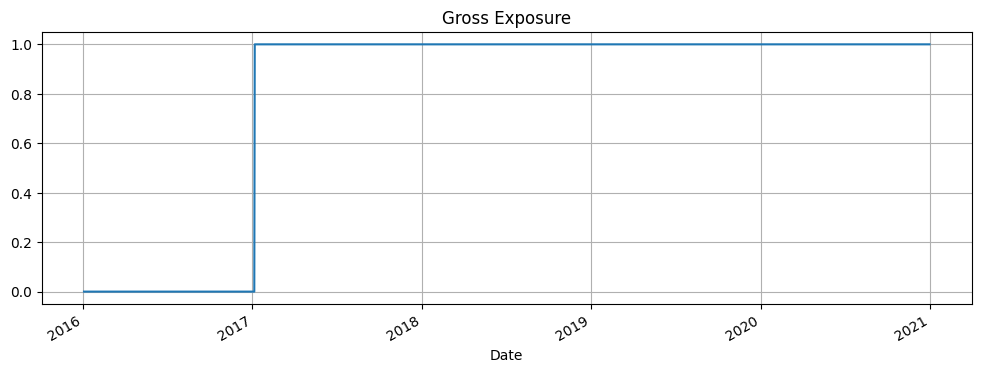

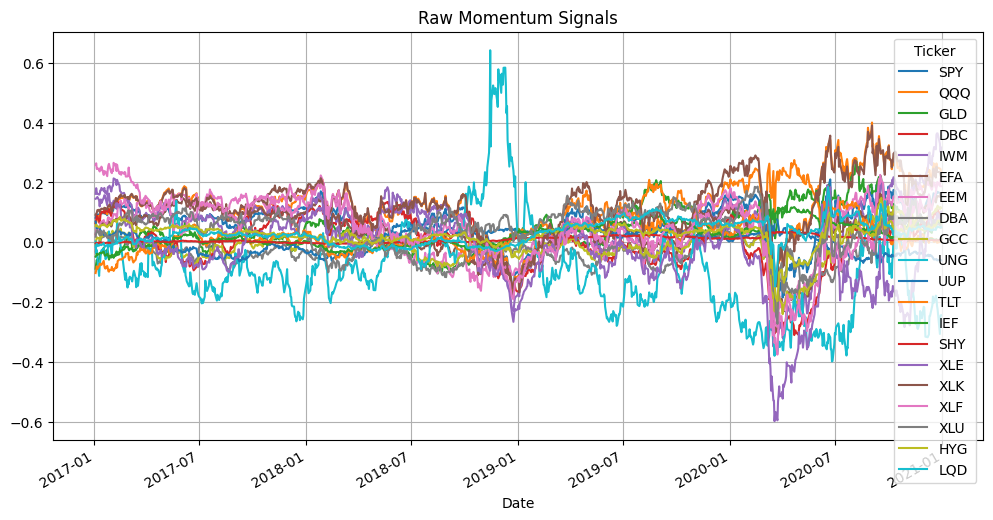

In [285]:
# ============================================================
# Relative + Absolute Momentum Cross-Asset Portfolio
# ============================================================
#
# Core Idea:
#
# - Absolute momentum:
#     determines long vs short direction
#
# - Relative momentum:
#     determines capital concentration
#
# Result:
# - strongest trends get largest weights
# - weakest trends get smallest / short weights
#
# ============================================================

start_date = "2016-01-01"
end_date = "2020-12-31"

tradable_assets = [
    "SPY",
    "QQQ",
    "GLD",
    "DBC",
    "IWM",
    "EFA",
    "EEM",
    "DBA",
    "GCC",
    "UNG",
    "UUP",
    "TLT",
    "IEF",
    "SHY",
    "XLE",
    "XLK",
    "XLF",
    "XLU",
    "HYG",
    "LQD"
]

# tradable_assets = [
#     "SPY",
#     "QQQ",
#     "DBC",
#     "GLD"
# ]

universe = tradable_assets

data = yf.download(
    universe,
    start=start_date,
    end=end_date
)

close_df = data["Close"].dropna()
prices = close_df[tradable_assets]

returns = np.log(
    prices / prices.shift(1)
)
spy_sharpe = returns['SPY'].mean() / returns['SPY'].std() * np.sqrt(252)
print('spy_sharpe:', spy_sharpe)
# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 5

vol_floor = 0.05

max_abs_weight = 0.50
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

# ------------------------------------------------------------
# Relative momentum concentration strength
#
# higher:
# - stronger concentration
# - more aggressive ranking tilt
#
# lower:
# - more diversified
#
# ============================================================

relative_strength_exponent = 2.0

# ============================================================
# Helper Functions
# ============================================================

def compute_momentum_ensemble(price_df):

    mom_3m = (
        price_df / price_df.shift(63) - 1
    )

    mom_6m = (
        price_df / price_df.shift(126) - 1
    )

    mom_12m = (
        price_df / price_df.shift(252) - 1
    )

    signal = (
        0.5 * mom_3m
        + 0.3 * mom_6m
        + 0.2 * mom_12m
    )

    return signal


def apply_inverse_vol_scaling(
    signal_df,
    returns,
    lookback,
    vol_floor
):

    realized_vol = (
        returns
        .rolling(lookback)
        .std()
        * np.sqrt(252)
    )

    realized_vol = realized_vol.clip(
        lower=vol_floor
    )

    scores = signal_df / realized_vol

    return scores


def apply_relative_momentum_overlay(
    scores,
    exponent=2.0
):
    """
    Convert raw scores into:
    - cross-sectional relative ranks
    - stronger concentration into best assets
    """

    # --------------------------------------------------------
    # Cross-sectional percentile rank
    # --------------------------------------------------------

    relative_rank = scores.rank(
        axis=1,
        pct=True
    )

    # --------------------------------------------------------
    # Center around zero
    #
    # 0.5 -> neutral
    #
    # Example:
    #
    # best asset:
    #     +0.5
    #
    # worst asset:
    #     -0.5
    #
    # --------------------------------------------------------

    relative_rank = (
        relative_rank - 0.5
    )

    # --------------------------------------------------------
    # Preserve sign of absolute trend
    #
    # If asset has negative absolute momentum:
    # - allow shorting
    #
    # --------------------------------------------------------

    directional_signal = np.sign(scores)

    # --------------------------------------------------------
    # Relative concentration
    # --------------------------------------------------------

    relative_strength = (
        relative_rank.abs() ** exponent
    )

    adjusted_scores = (
        directional_signal
        * relative_strength
        * scores.abs()
    )

    return adjusted_scores


def clean_scores(
    scores,
    allow_short=True,
    min_signal=0.00
):

    if allow_short:

        return scores.where(
            scores.abs() > min_signal,
            0.0
        )

    return scores.where(
        scores > min_signal,
        0.0
    )


def normalize_scores_to_weights(scores):

    gross_signal = (
        scores.abs().sum(axis=1)
    )

    weights = scores.div(
        gross_signal,
        axis=0
    )

    return weights.fillna(0.0)


def cap_and_renormalize(
    row,
    max_abs_weight
):

    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    if row.abs().sum() == 0:
        return row

    return (
        row / row.abs().sum()
    )


def apply_weight_caps(
    weights,
    max_abs_weight
):

    return weights.apply(
        cap_and_renormalize,
        axis=1,
        max_abs_weight=max_abs_weight
    )


def apply_rebalance(
    weights,
    rebalance_freq
):

    rebalance_mask = (
        np.arange(len(weights))
        % rebalance_freq
        == 0
    )

    weights_rebalanced = weights.copy()

    weights_rebalanced[
        ~rebalance_mask
    ] = np.nan

    return (
        weights_rebalanced
        .ffill()
        .fillna(0.0)
    )


def apply_gross_leverage_cap(
    weights,
    max_gross_leverage
):

    gross_leverage = (
        weights
        .abs()
        .sum(axis=1)
    )

    leverage_scalar = (
        max_gross_leverage
        / gross_leverage
    ).clip(upper=1.0).fillna(1.0)

    return weights.mul(
        leverage_scalar,
        axis=0
    )


def compute_performance(
    weights,
    returns
):

    pnl = (
        weights.shift(1)
        * returns
    )

    port_ret = (
        pnl.sum(axis=1)
        .dropna()
    )

    cum_pnl = np.exp(
        port_ret.cumsum()
    )

    sharpe = (
        port_ret.mean()
        / port_ret.std()
    ) * np.sqrt(252)

    ann_ret = (
        port_ret.mean() * 252
    )

    ann_vol = (
        port_ret.std() * np.sqrt(252)
    )

    drawdown = (
        cum_pnl
        / cum_pnl.cummax()
        - 1
    )

    max_dd = drawdown.min()

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .mean()
    )

    asset_pnl = pnl.sum()

    asset_sharpe = (
        pnl.mean()
        / pnl.std()
        * np.sqrt(252)
    )

    return {
        "pnl": pnl,
        "port_ret": port_ret,
        "cum_pnl": cum_pnl,
        "drawdown": drawdown,
        "sharpe": sharpe,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "max_dd": max_dd,
        "turnover": turnover,
        "asset_pnl": asset_pnl,
        "asset_sharpe": asset_sharpe,
    }

# ============================================================
# Signal Construction
# ============================================================

signal = compute_momentum_ensemble(
    prices
)

scores = apply_inverse_vol_scaling(
    signal,
    returns,
    lookback,
    vol_floor
)

# ============================================================
# NEW:
# Relative Momentum Overlay
# ============================================================

scores = apply_relative_momentum_overlay(
    scores,
    exponent=relative_strength_exponent
)

scores = clean_scores(
    scores,
    allow_short=allow_short,
    min_signal=min_signal
)

# ============================================================
# Weight Construction
# ============================================================

weights = normalize_scores_to_weights(
    scores
)

weights = apply_weight_caps(
    weights,
    max_abs_weight=max_abs_weight
)

weights = apply_rebalance(
    weights,
    rebalance_freq=rebalance_freq
)

weights = apply_gross_leverage_cap(
    weights,
    max_gross_leverage=max_gross_leverage
)

# ============================================================
# Backtest
# ============================================================

perf = compute_performance(
    weights,
    returns
)

pnl = perf["pnl"]
port_ret = perf["port_ret"]
cum_pnl = perf["cum_pnl"]
drawdown = perf["drawdown"]

sharpe = perf["sharpe"]
ann_ret = perf["ann_ret"]
ann_vol = perf["ann_vol"]
max_dd = perf["max_dd"]
turnover = perf["turnover"]

# ============================================================
# Results
# ============================================================

spy_sharpe = (
    returns.dropna()["SPY"].mean()
    / returns.dropna()["SPY"].std()
) * np.sqrt(252)

print("Sharpe:", round(sharpe, 2))
print("SPY Sharpe:", round(spy_sharpe, 2))

print(
    "Annualized Return:",
    round(ann_ret, 4)
)

print(
    "Annualized Vol:",
    round(ann_vol, 4)
)

print(
    "Max Drawdown:",
    round(max_dd, 4)
)

print(
    "Average Gross Leverage:",
    round(
        weights.abs().sum(axis=1).mean(),
        2
    )
)

print("Turnover:", turnover)

print("\nPnL")
print(perf["asset_pnl"])

print("\nAsset Sharpe")
print(perf["asset_sharpe"])

# ============================================================
# Charts
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Relative + Absolute Momentum Portfolio"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

weights.abs().sum(axis=1).plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)

plt.show()

signal.plot(
    figsize=(12, 6),
    title="Raw Momentum Signals",
    grid=True
)

plt.show()

## Sparse Selection and Fast Exits

[*********************100%***********************]  20 of 20 completed


spy_sharpe: 0.7525443075144472
Sharpe: 0.26
SPY Sharpe: 0.75
Annualized Return: 0.0266
Annualized Vol: 0.1027
Max Drawdown: -0.1407
Longest Drawdown: 737
Average Gross Leverage: 0.79
Turnover: 0.03950036564490174

PnL
Ticker
SPY    0.008120
QQQ    0.054640
GLD    0.010277
DBC   -0.016803
IWM    0.009207
EFA    0.015154
EEM    0.025108
DBA   -0.011178
GCC   -0.007037
UNG    0.021865
UUP    0.007098
TLT   -0.011173
IEF    0.011562
SHY    0.000749
XLE   -0.008459
XLK    0.067939
XLF    0.000310
XLU   -0.026543
HYG   -0.000513
LQD   -0.017673
dtype: float64

Asset Sharpe
Ticker
SPY    0.121914
QQQ    0.466829
GLD    0.178989
DBC   -0.275177
IWM    0.183588
EFA    0.356036
EEM    0.452101
DBA   -0.326752
GCC   -0.184392
UNG    0.096726
UUP    0.287842
TLT   -0.188690
IEF    0.379733
SHY    0.672208
XLE   -0.072364
XLK    0.612792
XLF    0.006080
XLU   -0.409938
HYG   -0.026633
LQD   -0.284067
dtype: float64


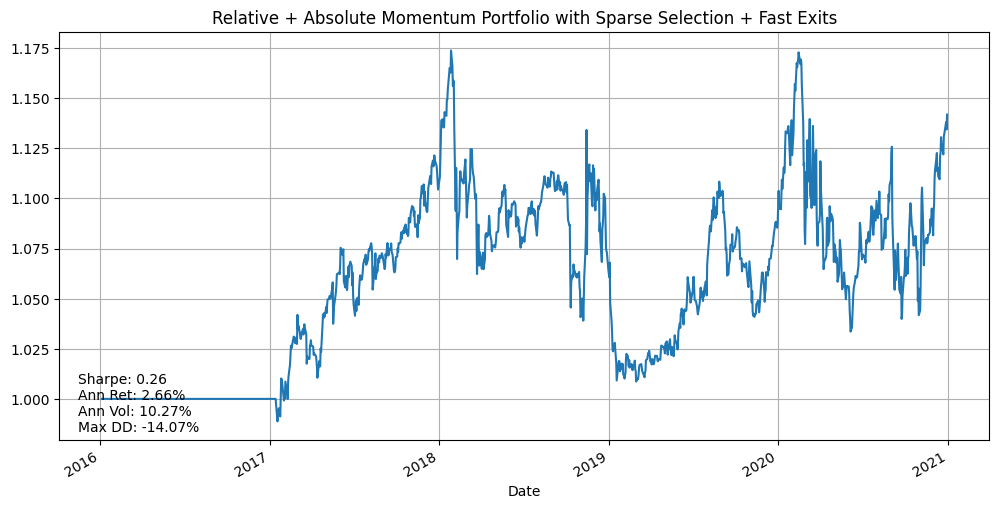

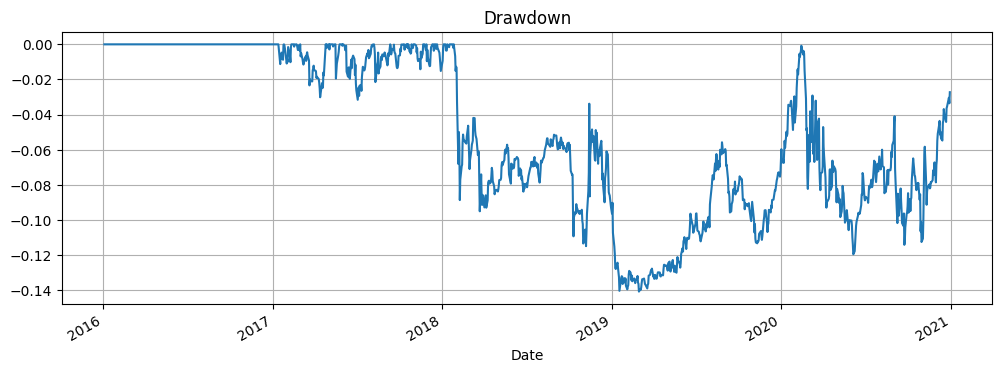

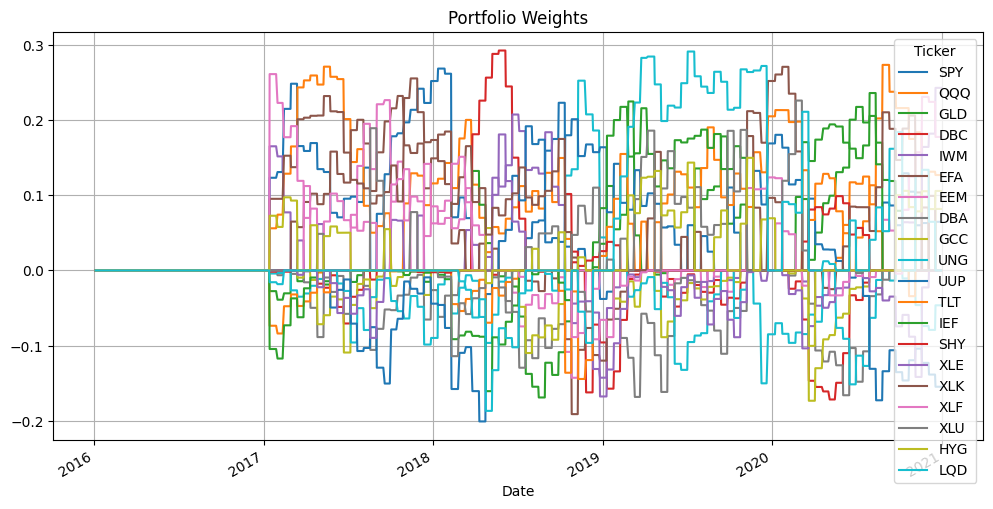

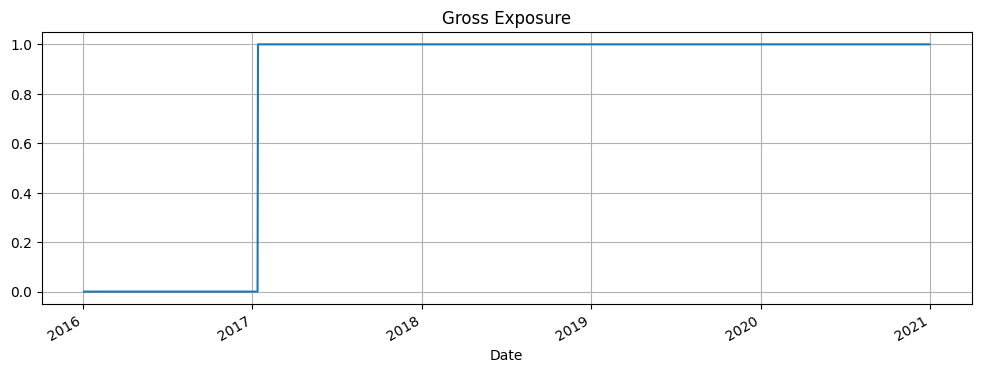

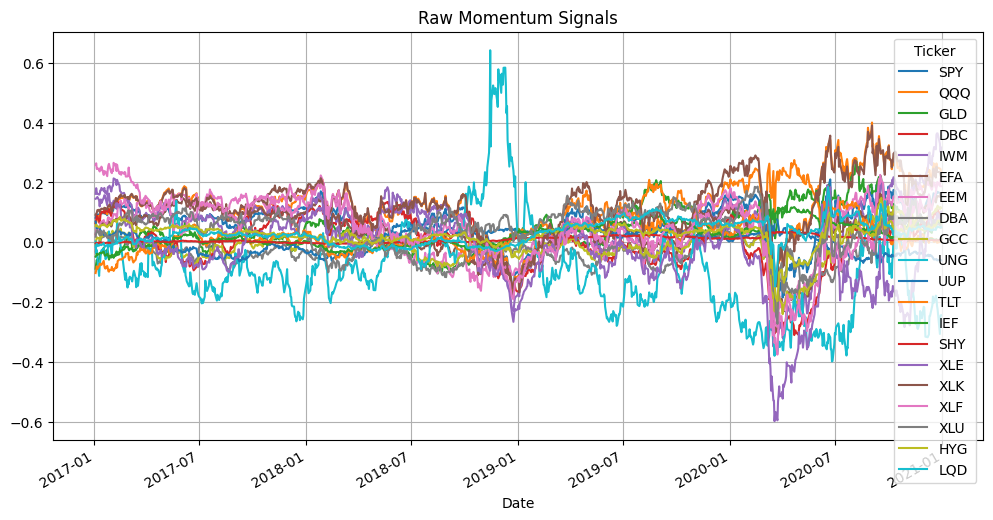

In [290]:
# ============================================================
# Relative + Absolute Momentum Cross-Asset Portfolio
# ============================================================
#
# NEW CHANGES:
#
# 1. Top / Bottom Sparse Selection
#    - only trade strongest N long candidates
#    - only trade weakest N short candidates
#
# 2. Fast Exit Overlay
#    - if short-term trend turns against the position,
#      flatten that asset before portfolio construction
#
# ============================================================

start_date = "2016-01-01"
end_date = "2020-12-31"

tradable_assets = [
    "SPY",
    "QQQ",
    "GLD",
    "DBC",
    "IWM",
    "EFA",
    "EEM",
    "DBA",
    "GCC",
    "UNG",
    "UUP",
    "TLT",
    "IEF",
    "SHY",
    "XLE",
    "XLK",
    "XLF",
    "XLU",
    "HYG",
    "LQD"
]

universe = tradable_assets

data = yf.download(
    universe,
    start=start_date,
    end=end_date
)

# IMPORTANT:
# Do not use dropna() globally across all assets unless you want
# to force every asset to have data on every date.
close_df = data["Close"]

prices = close_df[tradable_assets]

returns = np.log(
    prices / prices.shift(1)
)

returns = returns.dropna(how="all")

spy_returns = returns["SPY"].dropna()

spy_sharpe = (
    spy_returns.mean()
    / spy_returns.std()
    * np.sqrt(252)
)

print("spy_sharpe:", spy_sharpe)

# ============================================================
# Parameters
# ============================================================

lookback = 90
rebalance_freq = 10

vol_floor = 0.05

max_abs_weight = 0.50
max_gross_leverage = 1.0

allow_short = True
min_signal = 0.00

relative_strength_exponent = 1.25

# ------------------------------------------------------------
# NEW: Sparse selection parameters
# ------------------------------------------------------------
top_n_longs = 6
bottom_n_shorts = 6

# ------------------------------------------------------------
# NEW: Fast exit parameters
# ------------------------------------------------------------

fast_exit_lookback = 20

# If long and 1m momentum falls below this, exit.
long_exit_threshold = -0.02

# If short and 1m momentum rises above this, exit.
short_exit_threshold = 0.02

# ============================================================
# Helper Functions
# ============================================================

def compute_momentum_ensemble(price_df):
    mom_3m = (
        price_df / price_df.shift(63) - 1
    )
    mom_6m = (
        price_df / price_df.shift(126) - 1
    )
    mom_12m = (
        price_df / price_df.shift(252) - 1
    )

    signal = (
        0.5 * mom_3m
        + 0.3 * mom_6m
        + 0.2 * mom_12m
    )

    return signal


def apply_inverse_vol_scaling(
    signal_df,
    returns,
    lookback,
    vol_floor
):
    realized_vol = (
        returns
        .rolling(lookback)
        .std()
        * np.sqrt(252)
    )
    realized_vol = realized_vol.clip(
        lower=vol_floor
    )
    scores = signal_df / realized_vol

    return scores


def apply_relative_momentum_overlay(
    scores,
    exponent=2.0
):
    """
    Converts absolute trend scores into relative momentum scores.

    Absolute momentum:
    - controls sign/direction

    Relative momentum:
    - controls cross-sectional concentration
    """

    relative_rank = scores.rank(
        axis=1,
        pct=True
    )
    relative_rank = (
        relative_rank - 0.5
    )

    directional_signal = np.sign(scores)
    relative_strength = (
        relative_rank.abs() ** exponent
    )
    adjusted_scores = (
        directional_signal
        * relative_strength
        * scores.abs()
    )

    return adjusted_scores


def apply_fast_exit_overlay(
    scores,
    price_df,
    fast_exit_lookback,
    long_exit_threshold,
    short_exit_threshold
):
    """
    NEW:
    Fast exit logic.

    Purpose:
    - reduce long, slow drawdowns
    - exit stale trends faster than entry logic

    Rules:
    - If score is long but 1m momentum is weak/negative,
      set score to 0.

    - If score is short but 1m momentum is strongly positive,
      set score to 0.
    """

    fast_mom = (
        price_df / price_df.shift(fast_exit_lookback) - 1
    )

    scores = scores.copy()
    long_exit = (
        (scores > 0)
        & (fast_mom < long_exit_threshold)
    )
    short_exit = (
        (scores < 0)
        & (fast_mom > short_exit_threshold)
    )

    scores[long_exit] = 0.0
    scores[short_exit] = 0.0

    return scores


def apply_top_bottom_selection(
    scores,
    top_n_longs,
    bottom_n_shorts
):
    """
    NEW:
    Sparse top/bottom selection.

    Purpose:
    - concentrate capital in strongest trends
    - avoid spreading capital across mediocre assets

    Rules:
    - Long only the top N positive scores
    - Short only the bottom N negative scores
    """

    selected = pd.DataFrame(
        0.0,
        index=scores.index,
        columns=scores.columns
    )

    for date in scores.index:
        row = scores.loc[date].dropna()
        positive = row[row > 0]
        negative = row[row < 0]

        if len(positive) > 0:
            long_names = (
                positive
                .sort_values(ascending=False)
                .head(top_n_longs)
                .index
            )

            selected.loc[
                date,
                long_names
            ] = row.loc[long_names]

        if len(negative) > 0:
            short_names = (
                negative
                .sort_values(ascending=True)
                .head(bottom_n_shorts)
                .index
            )

            selected.loc[
                date,
                short_names
            ] = row.loc[short_names]

    return selected


def clean_scores(
    scores,
    allow_short=True,
    min_signal=0.00
):

    if allow_short:
        return scores.where(
            scores.abs() > min_signal,
            0.0
        )

    return scores.where(
        scores > min_signal,
        0.0
    )


def normalize_scores_to_weights(scores):
    gross_signal = (
        scores.abs().sum(axis=1)
    )

    weights = scores.div(
        gross_signal,
        axis=0
    )

    return weights.fillna(0.0)


def cap_and_renormalize(
    row,
    max_abs_weight
):

    row = row.copy()

    if row.abs().sum() == 0:
        return row

    row = row.clip(
        lower=-max_abs_weight,
        upper=max_abs_weight
    )

    if row.abs().sum() == 0:
        return row

    return (
        row / row.abs().sum()
    )


def apply_weight_caps(
    weights,
    max_abs_weight
):

    return weights.apply(
        cap_and_renormalize,
        axis=1,
        max_abs_weight=max_abs_weight
    )


def apply_rebalance(
    weights,
    rebalance_freq
):

    rebalance_mask = (
        np.arange(len(weights))
        % rebalance_freq
        == 0
    )

    weights_rebalanced = weights.copy()

    weights_rebalanced[
        ~rebalance_mask
    ] = np.nan

    return (
        weights_rebalanced
        .ffill()
        .fillna(0.0)
    )


def apply_gross_leverage_cap(
    weights,
    max_gross_leverage
):

    gross_leverage = (
        weights
        .abs()
        .sum(axis=1)
    )

    leverage_scalar = (
        max_gross_leverage
        / gross_leverage
    ).clip(upper=1.0).fillna(1.0)

    return weights.mul(
        leverage_scalar,
        axis=0
    )


def compute_performance(
    weights,
    returns
):

    pnl = (
        weights.shift(1)
        * returns
    )

    port_ret = (
        pnl.sum(axis=1)
        .dropna()
    )

    cum_pnl = np.exp(
        port_ret.cumsum()
    )

    sharpe = (
        port_ret.mean()
        / port_ret.std()
    ) * np.sqrt(252)

    ann_ret = (
        port_ret.mean() * 252
    )

    ann_vol = (
        port_ret.std() * np.sqrt(252)
    )

    drawdown = (
        cum_pnl
        / cum_pnl.cummax()
        - 1
    )

    max_dd = drawdown.min()

    turnover = (
        weights
        .diff()
        .abs()
        .sum(axis=1)
        .mean()
    )

    asset_pnl = pnl.sum()

    asset_sharpe = (
        pnl.mean()
        / pnl.std()
        * np.sqrt(252)
    )
    # ========================================================
    # Longest Drawdown Duration
    # ========================================================
    underwater = drawdown < 0
    drawdown_groups = (
        underwater != underwater.shift()
    ).cumsum()
    drawdown_durations = (
        underwater
        .groupby(drawdown_groups)
        .cumsum()
    )
    longest_drawdown_duration = (
        drawdown_durations.max()
    )

    return {
        "pnl": pnl,
        "port_ret": port_ret,
        "cum_pnl": cum_pnl,
        "drawdown": drawdown,
        "sharpe": sharpe,
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "max_dd": max_dd,
        "turnover": turnover,
        "asset_pnl": asset_pnl,
        "asset_sharpe": asset_sharpe,
        "longest_dd": longest_drawdown_duration
    }

# ============================================================
# Signal Construction
# ============================================================

signal = compute_momentum_ensemble(
    prices
)

scores = apply_inverse_vol_scaling(
    signal,
    returns,
    lookback,
    vol_floor
)

# ============================================================
# Relative Momentum Overlay
# ============================================================

scores = apply_relative_momentum_overlay(
    scores,
    exponent=relative_strength_exponent
)

# ============================================================
# NEW:
# Fast Exit Overlay
# ============================================================

# scores = apply_fast_exit_overlay(
#     scores=scores,
#     price_df=prices,
#     fast_exit_lookback=fast_exit_lookback,
#     long_exit_threshold=long_exit_threshold,
#     short_exit_threshold=short_exit_threshold
# )

scores = clean_scores(
    scores,
    allow_short=allow_short,
    min_signal=min_signal
)

# ============================================================
# NEW:
# Top / Bottom Sparse Selection
# ============================================================

scores = apply_top_bottom_selection(
    scores=scores,
    top_n_longs=top_n_longs,
    bottom_n_shorts=bottom_n_shorts
)

# ============================================================
# Weight Construction
# ============================================================

weights = normalize_scores_to_weights(
    scores
)

weights = apply_weight_caps(
    weights,
    max_abs_weight=max_abs_weight
)

weights = apply_rebalance(
    weights,
    rebalance_freq=rebalance_freq
)

weights = apply_gross_leverage_cap(
    weights,
    max_gross_leverage=max_gross_leverage
)

# ============================================================
# Backtest
# ============================================================

perf = compute_performance(
    weights,
    returns
)

pnl = perf["pnl"]
port_ret = perf["port_ret"]
cum_pnl = perf["cum_pnl"]
drawdown = perf["drawdown"]

sharpe = perf["sharpe"]
ann_ret = perf["ann_ret"]
ann_vol = perf["ann_vol"]
max_dd = perf["max_dd"]
turnover = perf["turnover"]
longest_dd = perf["longest_dd"]

# ============================================================
# Results
# ============================================================

spy_sharpe = (
    returns["SPY"].dropna().mean()
    / returns["SPY"].dropna().std()
) * np.sqrt(252)

print("Sharpe:", round(sharpe, 2))
print("SPY Sharpe:", round(spy_sharpe, 2))

print(
    "Annualized Return:",
    round(ann_ret, 4)
)

print(
    "Annualized Vol:",
    round(ann_vol, 4)
)

print(
    "Max Drawdown:",
    round(max_dd, 4)
)
print(
    "Longest Drawdown:",
    round(longest_dd, 2)
)

print(
    "Average Gross Leverage:",
    round(
        weights.abs().sum(axis=1).mean(),
        2
    )
)

print("Turnover:", turnover)

print("\nPnL")
print(perf["asset_pnl"])

print("\nAsset Sharpe")
print(perf["asset_sharpe"])

# ============================================================
# Charts
# ============================================================

ax = cum_pnl.plot(
    figsize=(12, 6),
    grid=True,
    title="Relative + Absolute Momentum Portfolio with Sparse Selection + Fast Exits"
)

plt.text(
    0.02,
    0.02,
    (
        f"Sharpe: {sharpe:.2f}\n"
        f"Ann Ret: {ann_ret:.2%}\n"
        f"Ann Vol: {ann_vol:.2%}\n"
        f"Max DD: {max_dd:.2%}"
    ),
    transform=ax.transAxes
)

plt.show()

drawdown.plot(
    figsize=(12, 4),
    title="Drawdown",
    grid=True
)

plt.show()

weights.plot(
    figsize=(12, 6),
    title="Portfolio Weights",
    grid=True
)

plt.show()

weights.abs().sum(axis=1).plot(
    figsize=(12, 4),
    title="Gross Exposure",
    grid=True
)

plt.show()

signal.plot(
    figsize=(12, 6),
    title="Raw Momentum Signals",
    grid=True
)

plt.show()